# Phase 2: Basic DeepONet (Hybrid Algebraic + Temporal)

## Architecture Overview

Phase 2 introduces a dual-pathway architecture based on the key insight from data analysis:
**some outputs have instantaneous (algebraic) relationships while others require temporal modeling.**

| Component | Temporal Pathway | Algebraic Pathway |
|---|---|---|
| **Purpose** | Dynamic outputs (T, p_prim, V_flow) | Instantaneous outputs (p_sec) |
| **Input** | 1200s history (whitened) + output history | Q_flow at prediction timesteps |
| **Architecture** | DeepONet (LSTM branch + Fourier trunk) | MLP (3-layer GELU) |
| **Prediction** | Delta (change from last value) | Absolute (normalized) |
| **Outputs** | 9 per CDU | 2 per CDU (p_sec_s, p_sec_r) |

### Key Innovations (vs Phase 1)
- **Output classification**: algebraic vs temporal based on cross-correlation analysis
- **Operator learning**: Branch-trunk decomposition for temporal outputs
- **Fourier trunk**: sinusoidal basis functions for smooth temporal interpolation
- **PCA input whitening**: decorrelates highly correlated input features
- **Separate loss weighting**: MSE for algebraic, Huber + variance matching for temporal

### Training Configuration
- **Optimizer**: AdamW (lr=1e-3, weight_decay=1e-4)
- **Scheduler**: Cosine annealing with warm restarts (T₀=20, T_mult=2)
- **Loss**: Huber (δ=0.5) + variance matching (temporal), MSE (algebraic)
- **Early stopping**: Patience 20 on combined validation loss
- **Data split**: 70% train / 15% val / 15% test (temporal, no shuffle)

In [ ]:
#  Imports and Device Configuration

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Set
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = min(16, os.cpu_count())
PIN_MEMORY = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla V100-PCIE-16GB
Memory: 16.9 GB


In [ ]:
#  Configuration

@dataclass
class DeepONetConfig:
    """Configuration for Phase 2: Basic DeepONet."""

    # ── Data ──────────────────────────────────────────────────────────────
    DATA_PATH: str = "../../summit/data/chunk_0/fmu_output_1.0hrs_operational.parquet"
    NUM_CDUS: int = 257
    CDU_IDS: List[int] = field(default_factory=lambda: list(range(1, 258)))
    TIME_COL: str = 'time'

    # ── Temporal windows ──────────────────────────────────────────────────
    SAMPLING_RATE_SEC: float = 1.0
    SUBSAMPLE_FACTOR: int = 30           # 5s effective resolution
    HISTORY_SECONDS: int = 1200          # 20 min of history
    PREDICTION_SECONDS: int = 30         # 60s ahead

    @property
    def HISTORY_STEPS(self) -> int:
        return int(self.HISTORY_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))

    @property
    def PREDICTION_STEPS(self) -> int:
        return int(self.PREDICTION_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))

    # ── Model ─────────────────────────────────────────────────────────────
    INCLUDE_OUTPUT_HISTORY: bool = True
    OUTPUT_HISTORY_STEPS: int = 10
    HIDDEN_SIZE: int = 128
    NUM_LAYERS: int = 2
    DROPOUT: float = 0.2

    # DeepONet architecture
    DEEPONET_HIDDEN: int = 64
    DEEPONET_N_BASIS: int = 32

    # Algebraic pathway
    ALGEBRAIC_HIDDEN: int = 64
    ALGEBRAIC_LAYERS: int = 3

    # Input whitening
    USE_INPUT_WHITENING: bool = True
    WHITENING_COMPONENTS: float = 0.99

    # ── Training ──────────────────────────────────────────────────────────
    BATCH_SIZE: int = 64
    LEARNING_RATE: float = 1e-3
    WEIGHT_DECAY: float = 1e-4
    GRADIENT_CLIP: float = 1.0
    MAX_EPOCHS: int = 150
    PATIENCE: int = 20

    TRAIN_RATIO: float = 0.7
    VAL_RATIO: float = 0.15
    TEST_RATIO: float = 0.15

    # ── Output classification ─────────────────────────────────────────────
    ALGEBRAIC_OUTPUTS: Set[str] = field(default_factory=lambda: {
        'p_sec_s_psig', 'p_sec_r_psig',
    })
    TEMPORAL_OUTPUTS: Set[str] = field(default_factory=lambda: {
        'V_flow_prim_GPM', 'V_flow_sec_GPM', 'W_flow_CDUP_kW',
        'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
        'p_prim_s_psig', 'p_prim_r_psig',
    })

    ALGEBRAIC_PRIMARY_INPUT: str = 'Q_flow'

    # ── Column patterns ───────────────────────────────────────────────────
    INPUT_PATTERNS: Dict = field(default_factory=lambda: {
        'Q_flow': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_Q_flow_total',
        'T_Air': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_T_Air',
        'T_ext': 'simulator_1_centralEnergyPlant_1_coolingTowerLoop_1_sources_T_ext',
    })

    OUTPUT_PATTERNS: Dict = field(default_factory=lambda: {
        'V_flow_prim_GPM': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.V_flow_prim_GPM',
        'V_flow_sec_GPM': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.V_flow_sec_GPM',
        'W_flow_CDUP_kW': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.W_flow_CDUP_kW',
        'T_prim_s_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_prim_s_C',
        'T_prim_r_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_prim_r_C',
        'T_sec_s_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_sec_s_C',
        'T_sec_r_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_sec_r_C',
        'p_prim_s_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_prim_s_psig',
        'p_prim_r_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_prim_r_psig',
        'p_sec_s_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_sec_s_psig',
        'p_sec_r_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_sec_r_psig',
    })

    OUTPUT_NAMES: List[str] = field(default_factory=lambda: [
        'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
        'V_flow_prim_GPM', 'V_flow_sec_GPM',
        'p_prim_s_psig', 'p_prim_r_psig', 'p_sec_s_psig', 'p_sec_r_psig',
        'W_flow_CDUP_kW',
    ])

    # ── Output Categories (from Chapter 5) ────────────────────────────────
    CATEGORY_A: List[str] = field(default_factory=lambda: [
        'T_prim_s_C', 'T_prim_r_C', 'p_prim_s_psig', 'p_prim_r_psig',
    ])
    CATEGORY_B: List[str] = field(default_factory=lambda: [
        'T_sec_s_C', 'T_sec_r_C',
    ])
    CATEGORY_C: List[str] = field(default_factory=lambda: [
        'V_flow_prim_GPM',
    ])
    CATEGORY_D: List[str] = field(default_factory=lambda: [
        'p_sec_s_psig', 'p_sec_r_psig',
    ])
    CATEGORY_E: List[str] = field(default_factory=lambda: [
        'V_flow_sec_GPM', 'W_flow_CDUP_kW',
    ])

    def get_output_type(self, col_name: str) -> str:
        """Determine if an output column is algebraic or temporal."""
        for algebraic_key in self.ALGEBRAIC_OUTPUTS:
            if algebraic_key in col_name:
                return 'algebraic'
        return 'temporal'

    def get_category(self, output_type: str) -> str:
        if output_type in self.CATEGORY_A: return 'A (Primary loop)'
        if output_type in self.CATEGORY_B: return 'B (Secondary temp)'
        if output_type in self.CATEGORY_C: return 'C (Primary flow)'
        if output_type in self.CATEGORY_D: return 'D (Secondary pressure)'
        if output_type in self.CATEGORY_E: return 'E (Constant)'
        return 'Unknown'

    def print_config(self):
        print("\n" + "=" * 70)
        print("PHASE 2: BASIC DEEPONET CONFIGURATION")
        print("=" * 70)
        print(f"History window:       {self.HISTORY_SECONDS}s ({self.HISTORY_STEPS} steps)")
        print(f"Prediction horizon:   {self.PREDICTION_SECONDS}s ({self.PREDICTION_STEPS} steps)")
        print(f"Subsample factor:     {self.SUBSAMPLE_FACTOR}s")
        print(f"Input whitening:      {self.USE_INPUT_WHITENING}")
        print(f"CDUs:                 {self.NUM_CDUS} ({self.CDU_IDS})")
        print(f"\nOutput Classification:")
        print(f"  Algebraic outputs:  {self.ALGEBRAIC_OUTPUTS}")
        print(f"  Temporal outputs:   {len(self.TEMPORAL_OUTPUTS)} types")
        print(f"\nDeepONet Architecture:")
        print(f"  Branch LSTM hidden: {self.DEEPONET_HIDDEN}")
        print(f"  Trunk hidden:       {self.DEEPONET_HIDDEN}")
        print(f"  N basis functions:  {self.DEEPONET_N_BASIS}")
        print(f"\nTraining:")
        print(f"  Learning rate:      {self.LEARNING_RATE}")
        print(f"  Batch size:         {self.BATCH_SIZE}")
        print(f"  Max epochs:         {self.MAX_EPOCHS}")
        print(f"  Patience:           {self.PATIENCE}")
        print("=" * 70)

config = DeepONetConfig()
config.print_config()


PHASE 2: BASIC DEEPONET CONFIGURATION
History window:       1200s (40 steps)
Prediction horizon:   30s (1 steps)
Subsample factor:     30s
Input whitening:      True
CDUs:                 257 ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183

In [ ]:
#  Normalizer and Whitening Classes

class ZScoreNormalizer:
    """Z-score (standardization) normalizer."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str]) -> 'ZScoreNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[:, i]
            self.stats[col] = {
                'mean': float(np.nanmean(col_data)),
                'std': float(np.nanstd(col_data) + 1e-8),
            }
        return self

    def transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        normalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            normalized[:, i] = (data[:, i] - s['mean']) / s['std']
        return normalized

    def inverse_transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        denormalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            denormalized[:, i] = data[:, i] * s['std'] + s['mean']
        return denormalized

    def fit_transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        self.fit(data, col_names)
        return self.transform(data, col_names)


class DeltaNormalizer:
    """Normalizer for delta (change) predictions — only for temporal outputs."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str],
            subsample_factor: int = 1) -> 'DeltaNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[::subsample_factor, i]
            deltas = np.diff(col_data)
            self.stats[col] = {
                'delta_mean': float(np.nanmean(deltas)),
                'delta_std': float(np.nanstd(deltas) + 1e-10),
                'delta_abs_max': float(np.abs(deltas).max() + 1e-10),
            }
        return self

    def get_scale(self, col: str) -> float:
        return self.stats[col]['delta_std'] * 10


class InputWhitener:
    """PCA-based input whitening for decorrelation."""

    def __init__(self, n_components: float = 0.99):
        self.n_components = n_components
        self.pca = None
        self.mean = None
        self.is_fitted = False

    def fit(self, data: np.ndarray) -> 'InputWhitener':
        self.mean = np.mean(data, axis=0)
        centered = data - self.mean
        self.pca = PCA(n_components=self.n_components, whiten=True)
        self.pca.fit(centered)
        self.is_fitted = True
        print(f"  InputWhitener: {data.shape[1]} → {self.pca.n_components_} components")
        print(f"  Explained variance: {self.pca.explained_variance_ratio_.sum():.2%}")
        return self

    def transform(self, data: np.ndarray) -> np.ndarray:
        if not self.is_fitted:
            raise RuntimeError("InputWhitener not fitted")
        centered = data - self.mean
        return self.pca.transform(centered).astype(np.float32)

    def fit_transform(self, data: np.ndarray) -> np.ndarray:
        self.fit(data)
        return self.transform(data)

    @property
    def output_dim(self) -> int:
        return self.pca.n_components_ if self.is_fitted else 0

print("Normalizers and whitener defined.")

Normalizers and whitener defined.


In [ ]:
#  Data Loading and Column Identification

def load_data(config: DeepONetConfig) -> pd.DataFrame:
    print(f"Loading data from: {config.DATA_PATH}")
    df = pd.read_parquet(config.DATA_PATH)
    if config.TIME_COL in df.columns:
        df = df.sort_values(config.TIME_COL).reset_index(drop=True)
    print(f"Loaded data shape: {df.shape}")
    print(f"Time range: {df[config.TIME_COL].min():.1f} to {df[config.TIME_COL].max():.1f}")
    return df


def identify_columns(df: pd.DataFrame, config: DeepONetConfig) -> Dict:
    """Identify input/output columns, classifying outputs as algebraic or temporal."""
    result = {
        'input_cols': [], 'output_cols': [],
        'algebraic_cols': [], 'temporal_cols': [],
        'col_to_cdu': {}, 'col_to_type': {},
    }

    # Input columns (per-CDU)
    for cdu_id in config.CDU_IDS:
        for pattern_name, pattern in config.INPUT_PATTERNS.items():
            if pattern_name == 'T_ext':
                continue
            col = pattern.format(cdu_id)
            if col in df.columns:
                result['input_cols'].append(col)

    # T_ext (global)
    t_ext_pattern = config.INPUT_PATTERNS.get('T_ext', '')
    if t_ext_pattern in df.columns:
        result['input_cols'].append(t_ext_pattern)
    else:
        for c in df.columns:
            if 't_ext' in c.lower() and c not in result['input_cols']:
                result['input_cols'].append(c)
                break

    # Output columns
    for output_name, pattern in config.OUTPUT_PATTERNS.items():
        for cdu_id in config.CDU_IDS:
            col = pattern.format(cdu_id)
            if col in df.columns:
                result['output_cols'].append(col)
                result['col_to_cdu'][col] = cdu_id
                result['col_to_type'][col] = output_name

    result['input_cols'] = list(dict.fromkeys(result['input_cols']))
    result['output_cols'] = list(dict.fromkeys(result['output_cols']))

    # Classify outputs
    result['algebraic_cols'] = [c for c in result['output_cols']
                                 if config.get_output_type(c) == 'algebraic']
    result['temporal_cols'] = [c for c in result['output_cols']
                                if config.get_output_type(c) == 'temporal']

    print(f"\n{'='*60}")
    print("COLUMN IDENTIFICATION")
    print(f"{'='*60}")
    print(f"Input columns:      {len(result['input_cols'])}")
    print(f"Output columns:     {len(result['output_cols'])}")
    print(f"  - Algebraic:      {len(result['algebraic_cols'])} (instantaneous)")
    print(f"  - Temporal:       {len(result['temporal_cols'])} (dynamical)")
    return result


def identify_qflow_columns(input_cols: List[str], config: DeepONetConfig) -> List[int]:
    """Identify indices of Q_flow columns for algebraic pathway."""
    qflow_indices = []
    for i, col in enumerate(input_cols):
        if config.ALGEBRAIC_PRIMARY_INPUT.lower() in col.lower():
            qflow_indices.append(i)
    print(f"  Q_flow columns:   {len(qflow_indices)} (indices: {qflow_indices[:3]}...)")
    return qflow_indices


df = load_data(config)
column_info = identify_columns(df, config)
qflow_indices = identify_qflow_columns(column_info['input_cols'], config)

Loading data from: ../../summit/data/chunk_0/fmu_output_1.0hrs_operational.parquet
Loaded data shape: (36000, 6430)
Time range: 2394.1 to 5994.0

COLUMN IDENTIFICATION
Input columns:      515
Output columns:     2827
  - Algebraic:      514 (instantaneous)
  - Temporal:       2313 (dynamical)
  Q_flow columns:   257 (indices: [0, 2, 4]...)


In [ ]:
#  Dataset

class HybridSurrogateDataset(Dataset):
    """
    Dataset providing separate data for algebraic and temporal pathways.

    - Algebraic outputs: absolute values (normalized), predicted from Q_flow only
    - Temporal outputs: delta predictions from input + output history
    """

    def __init__(
        self,
        input_data: np.ndarray,
        output_data: np.ndarray,
        config: DeepONetConfig,
        input_normalizer: ZScoreNormalizer,
        output_normalizer: ZScoreNormalizer,
        delta_normalizer: DeltaNormalizer,
        input_whitener: Optional[InputWhitener],
        column_info: Dict,
        qflow_indices: List[int],
        is_train: bool = True,
    ):
        self.config = config
        self.column_info = column_info
        self.qflow_indices = qflow_indices
        self.is_train = is_train

        self.algebraic_indices = [column_info['output_cols'].index(c)
                                   for c in column_info['algebraic_cols']]
        self.temporal_indices = [column_info['output_cols'].index(c)
                                  for c in column_info['temporal_cols']]

        # Subsample
        self.input_data = input_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)
        self.output_data = output_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)

        self.input_normalizer = input_normalizer
        self.output_normalizer = output_normalizer
        self.delta_normalizer = delta_normalizer
        self.input_whitener = input_whitener

        # Normalize inputs
        self.input_normalized = input_normalizer.transform(
            self.input_data, column_info['input_cols'])

        # Apply whitening if enabled
        if input_whitener is not None and config.USE_INPUT_WHITENING:
            self.input_whitened = input_whitener.transform(self.input_normalized)
        else:
            self.input_whitened = self.input_normalized

        # Normalize outputs
        self.output_normalized = output_normalizer.transform(
            self.output_data, column_info['output_cols'])

        total_required = config.HISTORY_STEPS + config.PREDICTION_STEPS
        self.n_samples = max(0, len(self.input_data) - total_required)

        if self.n_samples > 0:
            print(f"Dataset: {self.n_samples} samples | "
                  f"Algebraic: {len(self.algebraic_indices)} | "
                  f"Temporal: {len(self.temporal_indices)}")

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        H = self.config.HISTORY_STEPS
        K = self.config.PREDICTION_STEPS
        input_end = idx + H
        output_start = input_end
        output_end = output_start + K
        output_cols = self.column_info['output_cols']

        # ── Temporal pathway ──────────────────────────────────────────────
        x_temporal = self.input_whitened[idx:input_end]

        if self.config.INCLUDE_OUTPUT_HISTORY:
            out_hist_start = max(0, input_end - self.config.OUTPUT_HISTORY_STEPS)
            x_output_hist = self.output_normalized[out_hist_start:input_end]

            if x_output_hist.shape[0] < H:
                pad_len = H - x_output_hist.shape[0]
                padding = np.zeros((pad_len, x_output_hist.shape[1]), dtype=np.float32)
                x_output_hist = np.concatenate([padding, x_output_hist], axis=0)
            elif x_output_hist.shape[0] > H:
                x_output_hist = x_output_hist[-H:]

            temporal_hist = x_output_hist[:, self.temporal_indices]
            x_temporal = np.concatenate([x_temporal, temporal_hist], axis=1)

        # Temporal targets: delta prediction
        last_temporal_output = self.output_data[input_end - 1, self.temporal_indices]
        future_temporal = self.output_data[output_start:output_end][:, self.temporal_indices]
        temporal_deltas = future_temporal - last_temporal_output

        y_temporal = np.zeros_like(temporal_deltas)
        for i, col_idx in enumerate(self.temporal_indices):
            col = output_cols[col_idx]
            scale = self.delta_normalizer.get_scale(col)
            y_temporal[:, i] = temporal_deltas[:, i] / scale

        # ── Algebraic pathway ─────────────────────────────────────────────
        qflow_future = self.input_normalized[output_start:output_end][:, self.qflow_indices]
        qflow_current = self.input_normalized[input_end - 1, self.qflow_indices]
        y_algebraic = self.output_normalized[output_start:output_end][:, self.algebraic_indices]

        return {
            'x_temporal': torch.from_numpy(x_temporal).float(),
            'y_temporal': torch.from_numpy(y_temporal).float(),
            'last_temporal_output': torch.from_numpy(last_temporal_output).float(),
            'x_algebraic': torch.from_numpy(qflow_future).float(),
            'x_algebraic_current': torch.from_numpy(qflow_current).float(),
            'y_algebraic': torch.from_numpy(y_algebraic).float(),
            'last_output_full': torch.from_numpy(self.output_data[input_end - 1]).float(),
            'future_output_full': torch.from_numpy(
                self.output_data[output_start:output_end]).float(),
        }

print("HybridSurrogateDataset defined.")

HybridSurrogateDataset defined.


In [ ]:
#  Create Data Loaders

def create_dataloaders(
    df: pd.DataFrame,
    column_info: Dict,
    qflow_indices: List[int],
    config: DeepONetConfig,
) -> Tuple[DataLoader, DataLoader, DataLoader, Dict]:
    """Create train/val/test data loaders with normalization and whitening."""

    input_cols = column_info['input_cols']
    output_cols = column_info['output_cols']
    temporal_cols = column_info['temporal_cols']

    input_data = df[input_cols].values.astype(np.float32)
    output_data = df[output_cols].values.astype(np.float32)

    n_total = len(input_data)
    train_end = int(n_total * config.TRAIN_RATIO)
    val_end = int(n_total * (config.TRAIN_RATIO + config.VAL_RATIO))

    train_input, train_output = input_data[:train_end], output_data[:train_end]
    val_input, val_output = input_data[train_end:val_end], output_data[train_end:val_end]
    test_input, test_output = input_data[val_end:], output_data[val_end:]

    print(f"\nData split (contiguous temporal):")
    print(f"  Train: 0 → {train_end:,} ({train_end/n_total:.0%})")
    print(f"  Val:   {train_end:,} → {val_end:,} ({(val_end-train_end)/n_total:.0%})")
    print(f"  Test:  {val_end:,} → {n_total:,} ({(n_total-val_end)/n_total:.0%})")

    # Fit normalizers on training data
    print("\nFitting normalizers...")
    input_normalizer = ZScoreNormalizer().fit(train_input, input_cols)
    output_normalizer = ZScoreNormalizer().fit(train_output, output_cols)

    temporal_output_data = train_output[:, [output_cols.index(c) for c in temporal_cols]]
    delta_normalizer = DeltaNormalizer().fit(
        temporal_output_data, temporal_cols, config.SUBSAMPLE_FACTOR)

    # Input whitening
    input_whitener = None
    if config.USE_INPUT_WHITENING:
        print("\nFitting input whitener...")
        train_input_normalized = input_normalizer.transform(train_input, input_cols)
        train_input_subsampled = train_input_normalized[::config.SUBSAMPLE_FACTOR]
        input_whitener = InputWhitener(config.WHITENING_COMPONENTS).fit(train_input_subsampled)

    # Create datasets
    print("\nCreating datasets...")
    datasets = []
    for name, inp, out, is_train in [
        ('Train', train_input, train_output, True),
        ('Val', val_input, val_output, False),
        ('Test', test_input, test_output, False),
    ]:
        ds = HybridSurrogateDataset(
            inp, out, config, input_normalizer, output_normalizer,
            delta_normalizer, input_whitener, column_info, qflow_indices,
            is_train=is_train,
        )
        datasets.append(ds)

    train_loader = DataLoader(
        datasets[0], batch_size=config.BATCH_SIZE,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    )
    val_loader = DataLoader(
        datasets[1], batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    test_loader = DataLoader(
        datasets[2], batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )

    normalizers = {
        'input': input_normalizer,
        'output': output_normalizer,
        'delta': delta_normalizer,
        'whitener': input_whitener,
    }

    print(f"\nDataLoader sizes:")
    print(f"  Train: {len(train_loader)} batches")
    print(f"  Val:   {len(val_loader)} batches")
    print(f"  Test:  {len(test_loader)} batches")

    return train_loader, val_loader, test_loader, normalizers


train_loader, val_loader, test_loader, normalizers = create_dataloaders(
    df, column_info, qflow_indices, config)

# Verify shapes
sample_batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  x_temporal:    {sample_batch['x_temporal'].shape}")
print(f"  y_temporal:    {sample_batch['y_temporal'].shape}")
print(f"  x_algebraic:   {sample_batch['x_algebraic'].shape}")
print(f"  y_algebraic:   {sample_batch['y_algebraic'].shape}")


Data split (contiguous temporal):
  Train: 0 → 25,200 (70%)
  Val:   25,200 → 30,600 (15%)
  Test:  30,600 → 36,000 (15%)

Fitting normalizers...

Fitting input whitener...
  InputWhitener: 515 → 278 components
  Explained variance: 99.01%

Creating datasets...
Dataset: 799 samples | Algebraic: 514 | Temporal: 2313
Dataset: 139 samples | Algebraic: 514 | Temporal: 2313
Dataset: 139 samples | Algebraic: 514 | Temporal: 2313

DataLoader sizes:
  Train: 12 batches
  Val:   3 batches
  Test:  3 batches

Batch shapes:
  x_temporal:    torch.Size([64, 40, 2591])
  y_temporal:    torch.Size([64, 1, 2313])
  x_algebraic:   torch.Size([64, 1, 257])
  y_algebraic:   torch.Size([64, 1, 514])


## Model Architecture

### Temporal Pathway (DeepONet)
```
Branch Network:
  Input: (B, H=240, whitened_dim + temporal_output_hist)
    ├── 2-layer LSTM (64 hidden)
    ├── LayerNorm
    ├── Temporal Attention → context (64)
    └── Branch Head: Linear → LayerNorm → GELU → Linear(64 → n_basis × n_temporal_outputs)

Trunk Network:
  Input: query_times ∈ [0, 1] with Fourier features (sin/cos, 8 freqs)
    ├── Linear(17 → 64) → GELU
    ├── Linear(64 → 64) → GELU
    └── Linear(64 → n_basis=32)

Fusion: einsum('pn,bno→bpo', trunk, branch) → (B, K, n_temporal_outputs)
```

### Algebraic Pathway (MLP)
```
Input: (B, K, n_qflow) — Q_flow at each prediction timestep
  ├── Linear(n_qflow → 64) → LayerNorm → GELU → Dropout
  ├── Linear(64 → 64) → LayerNorm → GELU → Dropout
  └── Linear(64 → n_algebraic_outputs)
Output: (B, K, n_algebraic_outputs) — predicted p_sec values
```

In [ ]:
#  Algebraic Pathway Network

class AlgebraicPathway(nn.Module):
    """
    MLP for instantaneous (algebraic) relationships.
    Maps current Q_flow directly to secondary pressures.
    Based on analysis: p_sec = f(Q_flow) with R² > 0.96.
    """

    def __init__(
        self,
        input_size: int,
        output_size: int,
        hidden_size: int = 64,
        n_layers: int = 3,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size

        layers = []
        layers.extend([
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
        ])
        for _ in range(n_layers - 2):
            layers.extend([
                nn.Linear(hidden_size, hidden_size),
                nn.LayerNorm(hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
            ])
        layers.append(nn.Linear(hidden_size, output_size))
        self.mlp = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x_qflow: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x_qflow: (batch, prediction_steps, n_qflow_inputs)
        Returns:
            (batch, prediction_steps, n_algebraic_outputs)
        """
        batch_size, pred_steps, _ = x_qflow.shape
        x_flat = x_qflow.reshape(batch_size * pred_steps, -1)
        out_flat = self.mlp(x_flat)
        return out_flat.reshape(batch_size, pred_steps, -1)

print("AlgebraicPathway defined.")

AlgebraicPathway defined.


In [ ]:
#  Temporal DeepONet Pathway

class TemporalDeepONet(nn.Module):
    """
    DeepONet for temporal/dynamical outputs.
    Uses history to predict future deltas via branch-trunk decomposition.
    """

    def __init__(
        self,
        input_size: int,
        output_size: int,
        prediction_steps: int,
        lstm_hidden: int = 64,
        trunk_hidden: int = 64,
        n_basis: int = 32,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.output_size = output_size
        self.prediction_steps = prediction_steps
        self.n_basis = n_basis

        # Branch: encode history via LSTM + attention
        self.branch_encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            dropout=dropout,
        )
        self.branch_norm = nn.LayerNorm(lstm_hidden)

        self.attention = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden // 2),
            nn.Tanh(),
            nn.Linear(lstm_hidden // 2, 1),
        )

        # Branch head: output-specific basis coefficients
        self.branch_head = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden),
            nn.LayerNorm(lstm_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, n_basis * output_size),
        )

        # Trunk: Fourier features for query times
        self.register_buffer(
            'query_times',
            torch.linspace(0, 1, prediction_steps).view(-1, 1),
        )
        n_freqs = 8
        freqs = torch.linspace(1, n_freqs, n_freqs) * np.pi
        self.register_buffer('freqs', freqs)

        trunk_input_size = 1 + 2 * n_freqs
        self.trunk_net = nn.Sequential(
            nn.Linear(trunk_input_size, trunk_hidden),
            nn.GELU(),
            nn.Linear(trunk_hidden, trunk_hidden),
            nn.GELU(),
            nn.Linear(trunk_hidden, n_basis),
        )

        # Output scaling and bias
        self.output_scale = nn.Parameter(torch.ones(output_size) * 0.1)
        self.output_bias = nn.Parameter(torch.zeros(output_size))

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                nn.init.xavier_uniform_(param, gain=0.3)
            elif 'bias' in name and 'output_bias' not in name:
                nn.init.zeros_(param)

    def _get_trunk_features(self) -> torch.Tensor:
        t = self.query_times
        sin_features = torch.sin(t * self.freqs)
        cos_features = torch.cos(t * self.freqs)
        return torch.cat([t, sin_features, cos_features], dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch, history_steps, input_size)
        Returns:
            (batch, prediction_steps, output_size) predicted deltas
        """
        batch_size = x.shape[0]

        # Branch: encode history
        lstm_out, _ = self.branch_encoder(x)
        lstm_out = self.branch_norm(lstm_out)

        # Attention over time
        attn_weights = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(lstm_out * attn_weights, dim=1)

        # Branch output: basis coefficients per output
        branch_out = self.branch_head(context)
        branch_out = branch_out.view(batch_size, self.n_basis, self.output_size)

        # Trunk: encode query times
        trunk_features = self._get_trunk_features()
        trunk_out = self.trunk_net(trunk_features)  # (K, n_basis)

        # Combine: Hadamard-style via einsum
        out = torch.einsum('pn,bno->bpo', trunk_out, branch_out)

        # Scale and bias
        out = out * self.output_scale + self.output_bias
        return out

print("TemporalDeepONet defined.")

TemporalDeepONet defined.


In [ ]:
#  Hybrid Model

class HybridDeepONet(nn.Module):
    """
    Hybrid architecture combining:
    1. Algebraic pathway: MLP for Q_flow → p_sec (instantaneous)
    2. Temporal pathway: DeepONet for history → temporal output deltas
    """

    def __init__(
        self,
        temporal_input_size: int,
        temporal_output_size: int,
        algebraic_input_size: int,
        algebraic_output_size: int,
        prediction_steps: int,
        config: DeepONetConfig,
    ):
        super().__init__()
        self.temporal_output_size = temporal_output_size
        self.algebraic_output_size = algebraic_output_size
        self.prediction_steps = prediction_steps

        self.temporal_pathway = TemporalDeepONet(
            input_size=temporal_input_size,
            output_size=temporal_output_size,
            prediction_steps=prediction_steps,
            lstm_hidden=config.DEEPONET_HIDDEN,
            trunk_hidden=config.DEEPONET_HIDDEN,
            n_basis=config.DEEPONET_N_BASIS,
            dropout=config.DROPOUT,
        )

        self.algebraic_pathway = AlgebraicPathway(
            input_size=algebraic_input_size,
            output_size=algebraic_output_size,
            hidden_size=config.ALGEBRAIC_HIDDEN,
            n_layers=config.ALGEBRAIC_LAYERS,
            dropout=config.DROPOUT,
        )

        print(f"\nHybridDeepONet architecture:")
        print(f"  Temporal pathway: {temporal_input_size} → {temporal_output_size} (DeepONet)")
        print(f"  Algebraic pathway: {algebraic_input_size} → {algebraic_output_size} (MLP)")

    def forward(
        self,
        x_temporal: torch.Tensor,
        x_algebraic: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        y_temporal = self.temporal_pathway(x_temporal)
        y_algebraic = self.algebraic_pathway(x_algebraic)
        return y_temporal, y_algebraic


# Instantiate model
temporal_input_size = sample_batch['x_temporal'].shape[-1]
algebraic_input_size = sample_batch['x_algebraic'].shape[-1]
temporal_output_size = sample_batch['y_temporal'].shape[-1]
algebraic_output_size = sample_batch['y_algebraic'].shape[-1]

model = HybridDeepONet(
    temporal_input_size=temporal_input_size,
    temporal_output_size=temporal_output_size,
    algebraic_input_size=algebraic_input_size,
    algebraic_output_size=algebraic_output_size,
    prediction_steps=config.PREDICTION_STEPS,
    config=config,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
temporal_params = sum(p.numel() for p in model.temporal_pathway.parameters())
algebraic_params = sum(p.numel() for p in model.algebraic_pathway.parameters())

print(f"\nModel parameters:")
print(f"  Total:     {total_params:,}")
print(f"  Temporal:  {temporal_params:,}")
print(f"  Algebraic: {algebraic_params:,}")


HybridDeepONet architecture:
  Temporal pathway: 2591 → 2313 (DeepONet)
  Algebraic pathway: 257 → 514 (MLP)

Model parameters:
  Total:     5,597,397
  Temporal:  5,543,059
  Algebraic: 54,338


In [ ]:
#  Loss and Training Utilities

class HybridLoss(nn.Module):
    """Combined loss: Huber + variance matching for temporal, MSE for algebraic."""

    def __init__(
        self,
        temporal_weight: float = 1.0,
        algebraic_weight: float = 1.0,
        huber_delta: float = 0.5,
        var_weight: float = 0.1,
    ):
        super().__init__()
        self.temporal_weight = temporal_weight
        self.algebraic_weight = algebraic_weight
        self.huber = nn.HuberLoss(delta=huber_delta)
        self.mse = nn.MSELoss()
        self.var_weight = var_weight

    def forward(self, pred_temporal, target_temporal, pred_algebraic, target_algebraic):
        algebraic_loss = self.mse(pred_algebraic, target_algebraic)

        temporal_huber = self.huber(pred_temporal, target_temporal)
        pred_var = torch.var(pred_temporal, dim=(0, 1)) + 1e-8
        target_var = torch.var(target_temporal, dim=(0, 1)) + 1e-8
        var_ratio = torch.log(pred_var / target_var)
        var_loss = torch.mean(var_ratio ** 2)

        temporal_loss = temporal_huber + self.var_weight * var_loss

        total_loss = (self.temporal_weight * temporal_loss +
                      self.algebraic_weight * algebraic_loss)

        loss_dict = {
            'total': total_loss.item(),
            'temporal': temporal_loss.item(),
            'algebraic': algebraic_loss.item(),
            'temporal_huber': temporal_huber.item(),
            'var_match': var_loss.item(),
        }
        return total_loss, loss_dict


class EarlyStopping:
    def __init__(self, patience: int = 20, min_delta: float = 1e-6):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.should_stop = False
        self.best_state = None

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def load_best(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_epoch(model, loader, criterion, optimizer, device, gradient_clip=1.0):
    model.train()
    total_losses = {'total': 0, 'temporal': 0, 'algebraic': 0}
    n_batches = 0

    for batch in loader:
        x_temporal = batch['x_temporal'].to(device, non_blocking=True)
        x_algebraic = batch['x_algebraic'].to(device, non_blocking=True)
        y_temporal = batch['y_temporal'].to(device, non_blocking=True)
        y_algebraic = batch['y_algebraic'].to(device, non_blocking=True)

        optimizer.zero_grad()
        pred_temporal, pred_algebraic = model(x_temporal, x_algebraic)
        loss, loss_dict = criterion(pred_temporal, y_temporal, pred_algebraic, y_algebraic)

        if torch.isnan(loss):
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        optimizer.step()

        for key in total_losses:
            if key in loss_dict:
                total_losses[key] += loss_dict[key]
        n_batches += 1

    return {k: v / max(n_batches, 1) for k, v in total_losses.items()}


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_losses = {'total': 0, 'temporal': 0, 'algebraic': 0}
    n_batches = 0

    for batch in loader:
        x_temporal = batch['x_temporal'].to(device, non_blocking=True)
        x_algebraic = batch['x_algebraic'].to(device, non_blocking=True)
        y_temporal = batch['y_temporal'].to(device, non_blocking=True)
        y_algebraic = batch['y_algebraic'].to(device, non_blocking=True)

        pred_temporal, pred_algebraic = model(x_temporal, x_algebraic)
        loss, loss_dict = criterion(pred_temporal, y_temporal, pred_algebraic, y_algebraic)

        for key in total_losses:
            if key in loss_dict:
                total_losses[key] += loss_dict[key]
        n_batches += 1

    return {k: v / max(n_batches, 1) for k, v in total_losses.items()}

print("Training utilities defined.")

Training utilities defined.


## Training

In [ ]:
#  Training Loop

criterion = HybridLoss(
    temporal_weight=1.0,
    algebraic_weight=2.0,
    huber_delta=0.5,
    var_weight=0.1,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY,
)

scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
early_stopping = EarlyStopping(patience=config.PATIENCE)

history = {
    'train_total': [], 'train_temporal': [], 'train_algebraic': [],
    'val_total': [], 'val_temporal': [], 'val_algebraic': [],
    'lr': [],
}

print("\n" + "=" * 70)
print("TRAINING — Phase 2: Basic DeepONet")
print("=" * 70)

train_start_time = time.time()

pbar = tqdm(range(config.MAX_EPOCHS), desc="Training")
for epoch in pbar:
    train_losses = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE, config.GRADIENT_CLIP)
    val_losses = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    for key in ['total', 'temporal', 'algebraic']:
        history[f'train_{key}'].append(train_losses.get(key, 0))
        history[f'val_{key}'].append(val_losses.get(key, 0))
    history['lr'].append(optimizer.param_groups[0]['lr'])

    pbar.set_postfix({
        'trn': f"{train_losses['total']:.4f}",
        'val': f"{val_losses['total']:.4f}",
        'alg': f"{val_losses['algebraic']:.4f}",
        'tmp': f"{val_losses['temporal']:.4f}",
    })

    if early_stopping(val_losses['total'], model):
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break

early_stopping.load_best(model)
train_time = time.time() - train_start_time
n_epochs_trained = len(history['train_total'])

print(f"\nTraining complete.")
print(f"  Epochs trained:       {n_epochs_trained}")
print(f"  Best validation loss: {early_stopping.best_loss:.6f}")
print(f"  Training time:        {train_time:.1f}s ({train_time/60:.1f} min)")


TRAINING — Phase 2: Basic DeepONet


Training:   0%|          | 0/150 [00:00<?, ?it/s]


Early stopping at epoch 23

Training complete.
  Epochs trained:       23
  Best validation loss: 4.586687
  Training time:        42.3s (0.7 min)


## Training Details

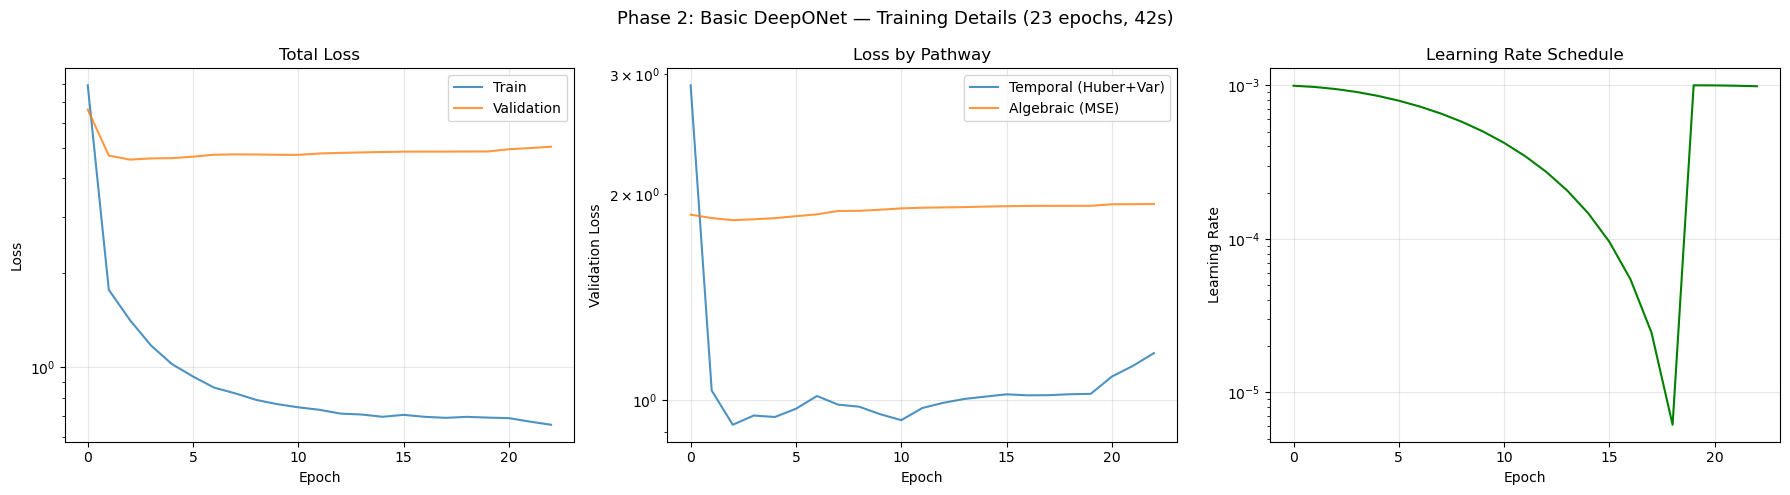

In [ ]:
#  Training Loss Curves

import os
os.makedirs('phase_2_vis', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total loss
axes[0].plot(history['train_total'], label='Train', linewidth=1.5, alpha=0.8)
axes[0].plot(history['val_total'], label='Validation', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Total Loss')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Pathway losses
axes[1].plot(history['val_temporal'], label='Temporal (Huber+Var)', linewidth=1.5, alpha=0.8)
axes[1].plot(history['val_algebraic'], label='Algebraic (MSE)', linewidth=1.5, alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Loss by Pathway')
axes[1].legend()
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['lr'], linewidth=1.5, color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Phase 2: Basic DeepONet — Training Details ({n_epochs_trained} epochs, {train_time:.0f}s)',
             fontsize=13)
plt.tight_layout()
plt.savefig('phase_2_vis/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

### Performance Metrics (from Chapter 3)

**Primary Accuracy Measures:** MAE, RMSE, R², Variance Ratio, Correlation Coefficient

**Delta Prediction Metrics:** Delta Std Ratio, Cumulative Drift Error

**Comparison Metrics:** Persistence R², Skill Score, Beats Persistence flag

**Computational Performance:** Training time, epochs, model parameters, inference time

In [ ]:
#  Collect Predictions

@torch.no_grad()
def collect_predictions(model, loader, config, normalizers, column_info, device):
    """Collect predictions from both pathways and convert to absolute values."""
    model.eval()
    temporal_cols = column_info['temporal_cols']
    algebraic_cols = column_info['algebraic_cols']
    output_cols = column_info['output_cols']

    all_pred_temporal, all_target_temporal = [], []
    all_pred_algebraic, all_target_algebraic = [], []
    all_last_temporal, all_last_full, all_future_full = [], [], []

    for batch in tqdm(loader, desc="Collecting predictions", leave=False):
        x_temporal = batch['x_temporal'].to(device, non_blocking=True)
        x_algebraic = batch['x_algebraic'].to(device, non_blocking=True)

        pred_temporal, pred_algebraic = model(x_temporal, x_algebraic)

        all_pred_temporal.append(pred_temporal.cpu().numpy())
        all_target_temporal.append(batch['y_temporal'].numpy())
        all_pred_algebraic.append(pred_algebraic.cpu().numpy())
        all_target_algebraic.append(batch['y_algebraic'].numpy())
        all_last_temporal.append(batch['last_temporal_output'].numpy())
        all_last_full.append(batch['last_output_full'].numpy())
        all_future_full.append(batch['future_output_full'].numpy())

    pred_temporal_norm = np.concatenate(all_pred_temporal)
    target_temporal_norm = np.concatenate(all_target_temporal)
    pred_algebraic_norm = np.concatenate(all_pred_algebraic)
    target_algebraic_norm = np.concatenate(all_target_algebraic)
    last_temporal = np.concatenate(all_last_temporal)
    last_full = np.concatenate(all_last_full)
    future_full = np.concatenate(all_future_full)

    # Convert temporal deltas to absolute
    delta_norm = normalizers['delta']
    temporal_pred_abs = np.zeros_like(pred_temporal_norm)
    temporal_target_abs = np.zeros_like(target_temporal_norm)
    for i, col in enumerate(temporal_cols):
        scale = delta_norm.get_scale(col)
        temporal_pred_abs[:, :, i] = last_temporal[:, i:i+1] + \
            np.cumsum(pred_temporal_norm[:, :, i] * scale, axis=1)
        temporal_target_abs[:, :, i] = last_temporal[:, i:i+1] + \
            np.cumsum(target_temporal_norm[:, :, i] * scale, axis=1)

    # Convert algebraic to absolute
    out_norm = normalizers['output']
    algebraic_pred_abs = np.zeros_like(pred_algebraic_norm)
    algebraic_target_abs = np.zeros_like(target_algebraic_norm)
    for step in range(pred_algebraic_norm.shape[1]):
        for i, col in enumerate(algebraic_cols):
            s = out_norm.stats[col]
            algebraic_pred_abs[:, step, i] = \
                pred_algebraic_norm[:, step, i] * s['std'] + s['mean']
            algebraic_target_abs[:, step, i] = \
                target_algebraic_norm[:, step, i] * s['std'] + s['mean']

    # Reconstruct combined predictions in original output order
    N = pred_temporal_norm.shape[0]
    K = config.PREDICTION_STEPS
    n_out = len(output_cols)
    pred_combined = np.zeros((N, K, n_out), dtype=np.float32)
    target_combined = np.zeros((N, K, n_out), dtype=np.float32)

    temporal_indices = [output_cols.index(c) for c in temporal_cols]
    algebraic_indices = [output_cols.index(c) for c in algebraic_cols]

    for i, idx in enumerate(temporal_indices):
        pred_combined[:, :, idx] = temporal_pred_abs[:, :, i]
        target_combined[:, :, idx] = temporal_target_abs[:, :, i]
    for i, idx in enumerate(algebraic_indices):
        pred_combined[:, :, idx] = algebraic_pred_abs[:, :, i]
        target_combined[:, :, idx] = algebraic_target_abs[:, :, i]

    return {
        'pred_absolute': pred_combined,
        'target_absolute': target_combined,
        'last_output': last_full,
        'pred_temporal_norm': pred_temporal_norm,
        'target_temporal_norm': target_temporal_norm,
        'temporal_pred_abs': temporal_pred_abs,
        'temporal_target_abs': temporal_target_abs,
        'algebraic_pred_abs': algebraic_pred_abs,
        'algebraic_target_abs': algebraic_target_abs,
    }


print("Collecting test predictions...")
inference_start = time.time()
predictions_dict = collect_predictions(
    model, test_loader, config, normalizers, column_info, DEVICE)
inference_time = time.time() - inference_start

n_test_samples = predictions_dict['pred_absolute'].shape[0]
n_outputs = predictions_dict['pred_absolute'].shape[2]
print(f"Predictions shape: {predictions_dict['pred_absolute'].shape}")
print(f"Inference time: {inference_time:.2f}s ({inference_time/n_test_samples*1000:.2f} ms/sample)")

Predictions shape: (139, 1, 2827)
Inference time: 1.19s (8.56 ms/sample)


In [ ]:
#  Compute Comprehensive Metrics

def compute_metrics(predictions_dict, column_info, config):
    """Compute per-output metrics matching Chapter 3 evaluation criteria."""
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_out = predictions_dict['last_output']
    output_cols = column_info['output_cols']
    K = config.PREDICTION_STEPS

    results = []
    for i, col in enumerate(output_cols):
        p = pred[:, :, i].flatten()
        t = target[:, :, i].flatten()

        mae = np.mean(np.abs(p - t))
        rmse = np.sqrt(np.mean((p - t) ** 2))

        ss_res = np.sum((t - p) ** 2)
        ss_tot = np.sum((t - t.mean()) ** 2)
        r2 = 1 - ss_res / (ss_tot + 1e-10)

        var_pred = np.var(p)
        var_true = np.var(t)
        variance_ratio = var_pred / (var_true + 1e-10)

        if np.std(p) > 1e-10 and np.std(t) > 1e-10:
            correlation = np.corrcoef(p, t)[0, 1]
        else:
            correlation = 0.0

        # Persistence baseline
        last_val = last_out[:, i]
        persistence = np.repeat(last_val[:, np.newaxis], K, axis=1).flatten()
        ss_res_pers = np.sum((t - persistence) ** 2)
        r2_pers = 1 - ss_res_pers / (ss_tot + 1e-10)
        skill_score = (r2 - r2_pers) / (1 - r2_pers + 1e-10)

        # Delta metrics (for temporal outputs only)
        output_type = column_info['col_to_type'].get(col, 'Unknown')
        pathway = config.get_output_type(col)

        delta_std_ratio = np.nan
        cumulative_drift = 0.0
        if pathway == 'temporal':
            t_idx = column_info['temporal_cols'].index(col) if col in column_info['temporal_cols'] else None
            if t_idx is not None:
                pred_d = predictions_dict['pred_temporal_norm'][:, :, t_idx].flatten()
                targ_d = predictions_dict['target_temporal_norm'][:, :, t_idx].flatten()
                delta_std_ratio = np.std(pred_d) / (np.std(targ_d) + 1e-10)
                if K > 1:
                    t_pred_abs = predictions_dict['temporal_pred_abs']
                    t_targ_abs = predictions_dict['temporal_target_abs']
                    cumulative_drift = np.mean(np.abs(t_pred_abs[:, -1, t_idx] - t_targ_abs[:, -1, t_idx])) - \
                                       np.mean(np.abs(t_pred_abs[:, 0, t_idx] - t_targ_abs[:, 0, t_idx]))

        # Per-step R²
        step_r2 = []
        for k in range(K):
            pk = pred[:, k, i]
            tk = target[:, k, i]
            ss_res_k = np.sum((tk - pk) ** 2)
            ss_tot_k = np.sum((tk - tk.mean()) ** 2)
            step_r2.append(1 - ss_res_k / (ss_tot_k + 1e-10))

        cdu_id = column_info['col_to_cdu'].get(col, 'Unknown')
        category = config.get_category(output_type)

        results.append({
            'Output': col,
            'CDU': cdu_id,
            'Type': output_type,
            'Category': category,
            'Pathway': pathway,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2,
            'Variance_Ratio': variance_ratio,
            'Correlation': correlation,
            'Delta_Std_Ratio': delta_std_ratio,
            'Cumulative_Drift': cumulative_drift,
            'Persistence_R²': r2_pers,
            'Beats_Persistence': r2 > r2_pers,
            'Skill_Score': skill_score,
            **{f'R²_step{k+1}': step_r2[k] for k in range(K)},
        })

    return pd.DataFrame(results)


metrics_df = compute_metrics(predictions_dict, column_info, config)
print(f"Metrics computed for {len(metrics_df)} outputs.")

Metrics computed for 2827 outputs.


In [ ]:
#  Results Summary — Overall, Per-Category, Per-Pathway

print("\n" + "=" * 70)
print("RESULTS SUMMARY — Phase 2: Basic DeepONet")
print("=" * 70)

# Overall
print(f"\n--- All {len(metrics_df)} Outputs ---")
print(f"  Mean R²:           {metrics_df['R²'].mean():.4f}")
print(f"  Median R²:         {metrics_df['R²'].median():.4f}")
print(f"  Min R²:            {metrics_df['R²'].min():.4f}")
print(f"  Max R²:            {metrics_df['R²'].max():.4f}")
print(f"  Std R²:            {metrics_df['R²'].std():.4f}")
print(f"  Beats Persistence: {metrics_df['Beats_Persistence'].sum()}/{len(metrics_df)} "
      f"({metrics_df['Beats_Persistence'].mean():.1%})")
print(f"  Mean Skill Score:  {metrics_df['Skill_Score'].mean():.4f}")

# Per pathway
print(f"\n--- Per Pathway ---")
for pathway in ['temporal', 'algebraic']:
    pw_df = metrics_df[metrics_df['Pathway'] == pathway]
    print(f"\n  {pathway.upper()} ({len(pw_df)} outputs):")
    print(f"    Mean R²:         {pw_df['R²'].mean():.4f}")
    print(f"    Median R²:       {pw_df['R²'].median():.4f}")
    print(f"    Variance Ratio:  {pw_df['Variance_Ratio'].mean():.4f}")
    print(f"    Beats Persist:   {pw_df['Beats_Persistence'].sum()}/{len(pw_df)}")

# Per-category summary
print(f"\n--- Per-Category Performance ---")
cat_summary = metrics_df.groupby('Category').agg({
    'R²': ['mean', 'median', 'min', 'max', 'count'],
    'RMSE': 'mean',
    'Variance_Ratio': 'mean',
    'Beats_Persistence': 'mean',
}).round(4)
print(cat_summary.to_string())

# Per output-type summary
print(f"\n--- Per Output Type ---")
type_summary = metrics_df.groupby('Type').agg({
    'R²': ['mean', 'median', 'min', 'max'],
    'RMSE': 'mean',
    'MAE': 'mean',
    'Variance_Ratio': 'mean',
    'Correlation': 'mean',
    'Beats_Persistence': 'mean',
}).round(4)
print(type_summary.to_string())

# R² distribution
print(f"\n--- R² Distribution ---")
for threshold, label in [(0.99, '≥ 0.99'), (0.95, '≥ 0.95'), (0.90, '≥ 0.90'),
                          (0.80, '≥ 0.80'), (0.50, '≥ 0.50'), (0.0, '≥ 0.00')]:
    count = (metrics_df['R²'] >= threshold).sum()
    print(f"  R² {label}: {count}/{len(metrics_df)} ({count/len(metrics_df):.1%})")
count_neg = (metrics_df['R²'] < 0).sum()
print(f"  R² < 0.00: {count_neg}/{len(metrics_df)} ({count_neg/len(metrics_df):.1%})")

# Computational summary
print(f"\n--- Computational Performance ---")
print(f"  Model Parameters:     {total_params:,}")
print(f"    Temporal:           {temporal_params:,}")
print(f"    Algebraic:          {algebraic_params:,}")
print(f"  Training Epochs:      {n_epochs_trained}")
print(f"  Training Time:        {train_time:.1f}s ({train_time/60:.1f} min)")
print(f"  Inference Time:       {inference_time:.2f}s")
print(f"  Per sample:           {inference_time/n_test_samples*1000:.2f} ms")

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/opt/conda/lib/python3.12/multiprocessing/connection.py", line 178, in close
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
Exception ignored in: <function _ConnectionBase.__del__ at 0x7f285b365120>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/multiprocessing/connection.py", line 133, in __del__
    reader_close()
  File "/opt/conda/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/opt/conda/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    self._close()
  File "/opt/conda/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    self._close()
  File "/opt/conda/lib/python3.12/multiprocessing/connectio


RESULTS SUMMARY — Phase 2: Basic DeepONet

--- All 2827 Outputs ---
  Mean R²:           0.0993
  Median R²:         0.9900
  Min R²:            -41.2199
  Max R²:            0.9999
  Std R²:            2.5082
  Beats Persistence: 144/2827 (5.1%)
  Mean Skill Score:  -9.0934

--- Per Pathway ---

  TEMPORAL (2313 outputs):
    Mean R²:         0.6473
    Median R²:       0.9937
    Variance Ratio:  1.0797
    Beats Persist:   140/2313

  ALGEBRAIC (514 outputs):
    Mean R²:         -2.3670
    Median R²:       -0.7508
    Variance Ratio:  0.1443
    Beats Persist:   4/514

--- Per-Category Performance ---
                            R²                                   RMSE Variance_Ratio Beats_Persistence
                          mean  median      min     max count    mean           mean              mean
Category                                                                                              
A (Primary loop)        0.9933  0.9965   0.4672  0.9999  1028  0.0015       

## Evaluation Metric Visualizations

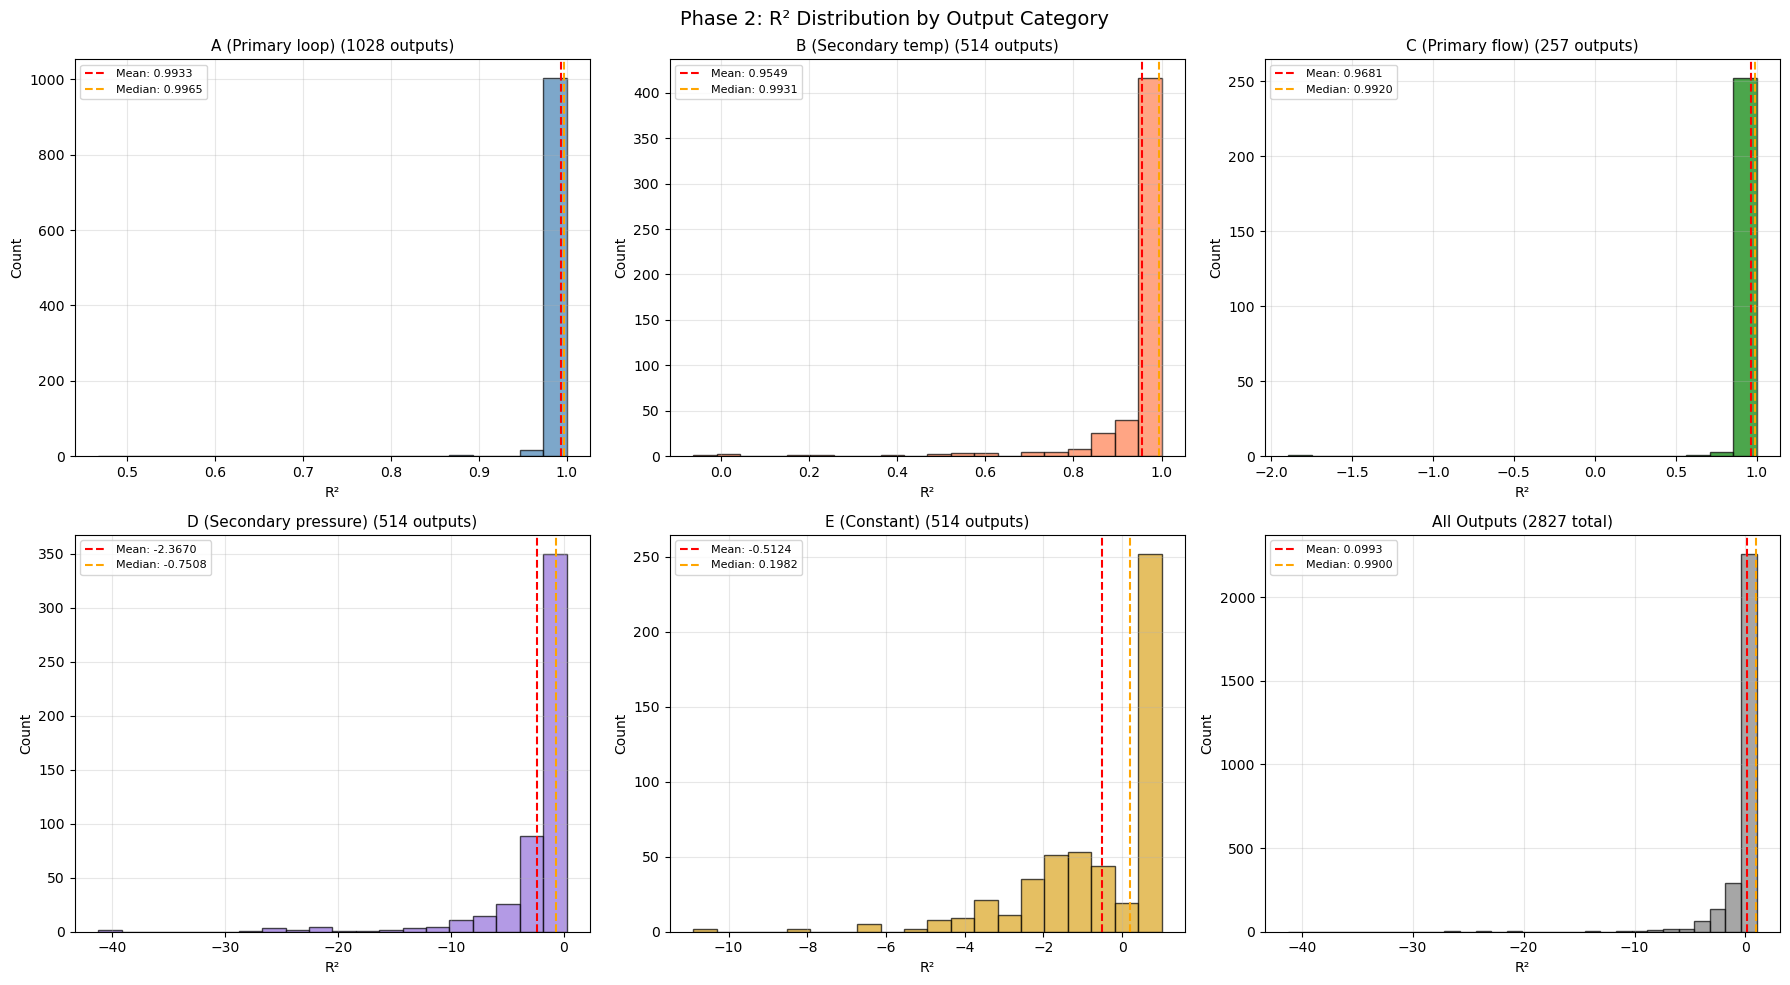

In [ ]:
#  Visualization 1 — R² Distribution by Category

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

categories = ['A (Primary loop)', 'B (Secondary temp)', 'C (Primary flow)',
              'D (Secondary pressure)', 'E (Constant)']
colors = ['steelblue', 'coral', 'green', 'mediumpurple', 'goldenrod']

for idx, (cat, color) in enumerate(zip(categories, colors)):
    ax = axes[idx]
    cat_data = metrics_df[metrics_df['Category'] == cat]['R²']
    if len(cat_data) == 0:
        ax.set_visible(False)
        continue
    ax.hist(cat_data, bins=min(20, len(cat_data)), alpha=0.7,
            edgecolor='black', color=color)
    ax.axvline(cat_data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {cat_data.mean():.4f}')
    ax.axvline(cat_data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {cat_data.median():.4f}')
    ax.set_title(f'{cat} ({len(cat_data)} outputs)', fontsize=11)
    ax.set_xlabel('R²')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

ax = axes[5]
ax.hist(metrics_df['R²'], bins=30, alpha=0.7, edgecolor='black', color='gray')
ax.axvline(metrics_df['R²'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {metrics_df["R²"].mean():.4f}')
ax.axvline(metrics_df['R²'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {metrics_df["R²"].median():.4f}')
ax.set_title(f'All Outputs ({len(metrics_df)} total)', fontsize=11)
ax.set_xlabel('R²')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Phase 2: R² Distribution by Output Category', fontsize=14)
plt.tight_layout()
plt.savefig('phase_2_vis/r2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

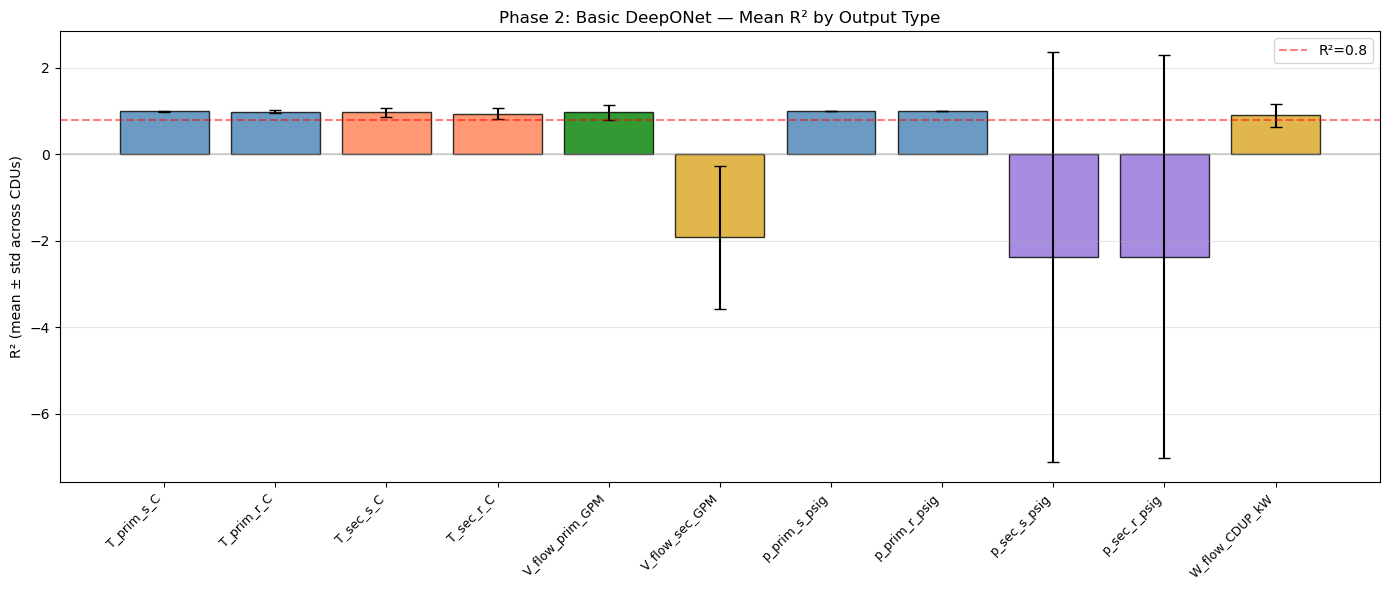

In [ ]:
#  Visualization 2 — Per-Output-Type R² Bar Chart

output_types = config.OUTPUT_NAMES
type_means = metrics_df.groupby('Type')['R²'].agg(['mean', 'std']).reindex(output_types)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(output_types))
bars = ax.bar(x, type_means['mean'], yerr=type_means['std'], capsize=4,
              color='steelblue', alpha=0.8, edgecolor='black')

color_map = {
    'A (Primary loop)': 'steelblue', 'B (Secondary temp)': 'coral',
    'C (Primary flow)': 'green', 'D (Secondary pressure)': 'mediumpurple',
    'E (Constant)': 'goldenrod',
}
for i, otype in enumerate(output_types):
    cat = config.get_category(otype)
    bars[i].set_facecolor(color_map.get(cat, 'gray'))

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('R² (mean ± std across CDUs)')
ax.set_title('Phase 2: Basic DeepONet — Mean R² by Output Type')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='R²=0.8')
ax.axhline(y=0.0, color='gray', linestyle='-', alpha=0.3)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_2_vis/r2_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

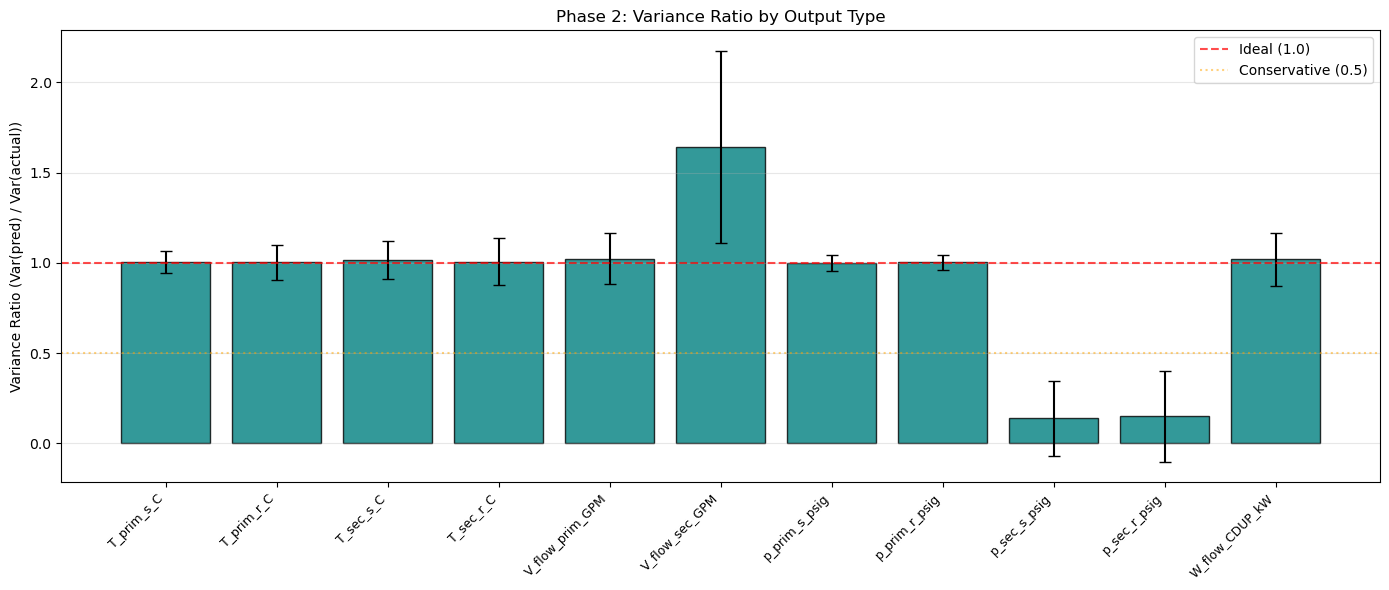

In [ ]:
#  Visualization 3 — Variance Ratio by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_var = metrics_df.groupby('Type')['Variance_Ratio'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_var['mean'], yerr=type_var['std'], capsize=4,
              color='teal', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Variance Ratio (Var(pred) / Var(actual))')
ax.set_title('Phase 2: Variance Ratio by Output Type')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Ideal (1.0)')
ax.axhline(y=0.5, color='orange', linestyle=':', alpha=0.5, label='Conservative (0.5)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_2_vis/variance_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

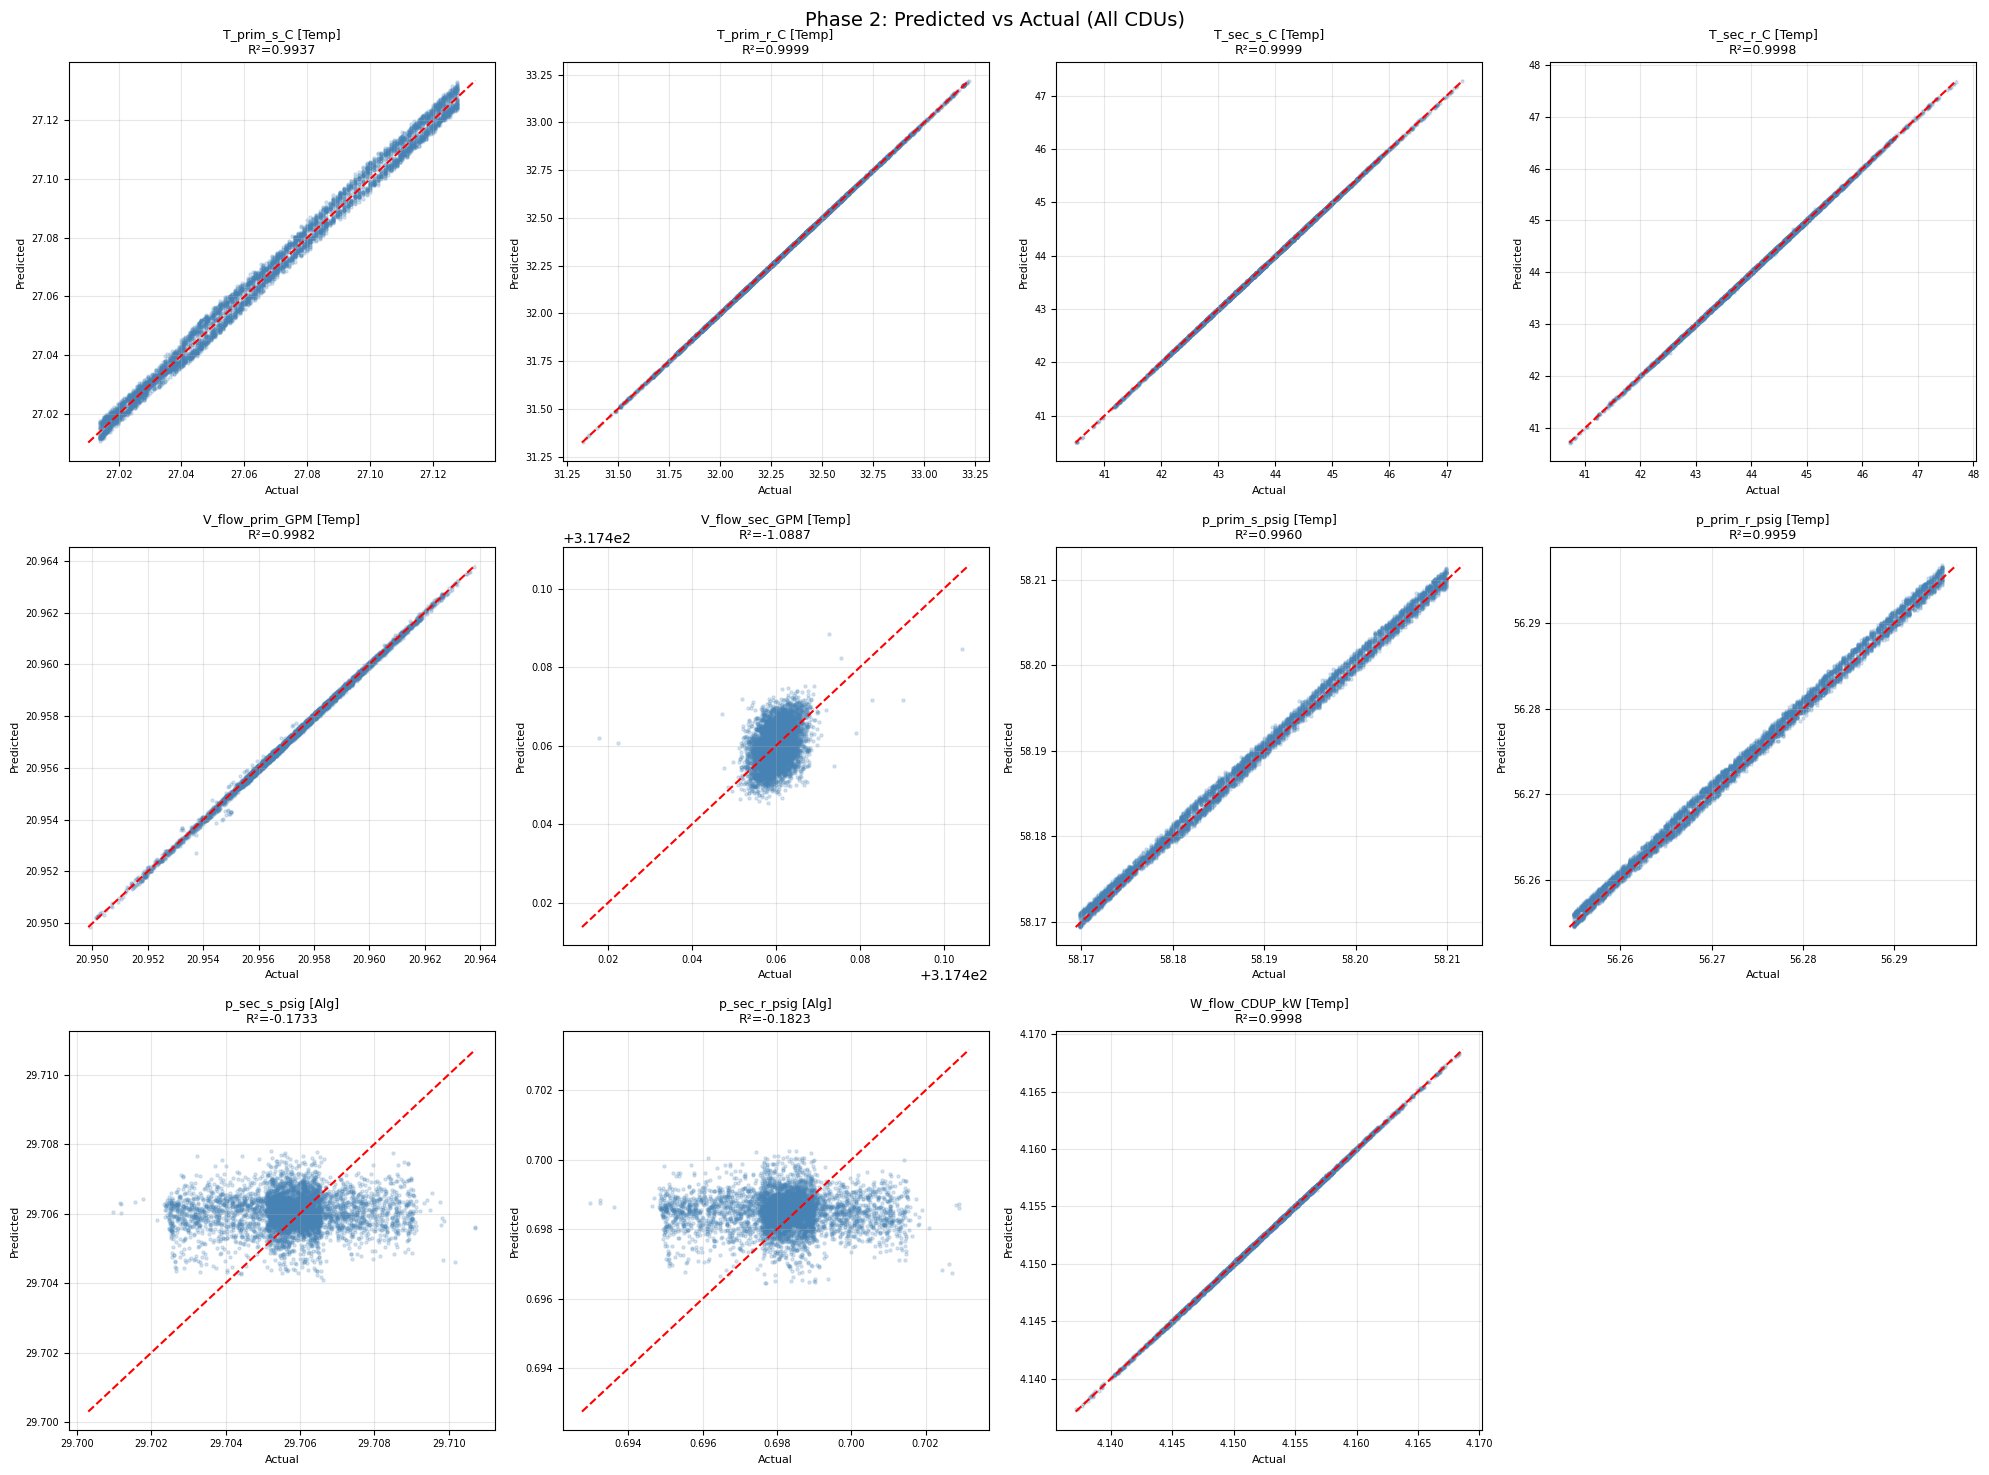

In [ ]:
#  Visualization 4 — Scatter Plots per Output Type

pred = predictions_dict['pred_absolute']
target = predictions_dict['target_absolute']
output_cols = column_info['output_cols']

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for idx, output_type in enumerate(config.OUTPUT_NAMES):
    if idx >= len(axes):
        break
    ax = axes[idx]

    all_pred, all_target = [], []
    for col_idx, col in enumerate(output_cols):
        if column_info['col_to_type'].get(col) == output_type:
            all_pred.append(pred[:, :, col_idx].flatten())
            all_target.append(target[:, :, col_idx].flatten())

    if len(all_pred) == 0:
        ax.set_visible(False)
        continue

    all_pred = np.concatenate(all_pred)
    all_target = np.concatenate(all_target)

    n_plot = min(5000, len(all_pred))
    plot_idx = np.random.choice(len(all_pred), n_plot, replace=False)

    ax.scatter(all_target[plot_idx], all_pred[plot_idx], alpha=0.2, s=5, c='steelblue')
    vmin = min(all_target.min(), all_pred.min())
    vmax = max(all_target.max(), all_pred.max())
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.5)

    ss_res = np.sum((all_target - all_pred) ** 2)
    ss_tot = np.sum((all_target - all_target.mean()) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-10)

    pathway = 'Alg' if config.get_output_type(output_type + '_placeholder') == 'algebraic' \
        else ('Alg' if output_type in config.ALGEBRAIC_OUTPUTS else 'Temp')
    ax.set_title(f'{output_type} [{pathway}]\nR²={r2:.4f}', fontsize=9)
    ax.set_xlabel('Actual', fontsize=8)
    ax.set_ylabel('Predicted', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

for idx in range(len(config.OUTPUT_NAMES), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Phase 2: Predicted vs Actual (All CDUs)', fontsize=14)
plt.tight_layout()
plt.savefig('phase_2_vis/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

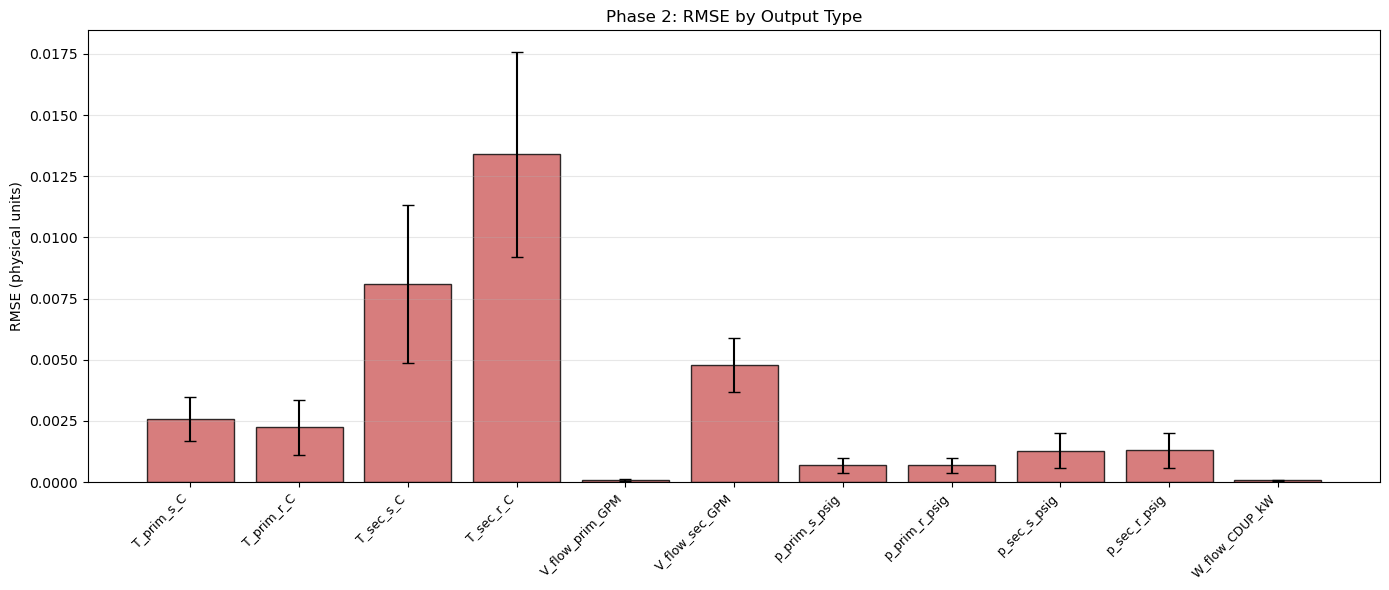

In [ ]:
#  Visualization 5 — RMSE by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_rmse = metrics_df.groupby('Type')['RMSE'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_rmse['mean'], yerr=type_rmse['std'], capsize=4,
              color='indianred', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('RMSE (physical units)')
ax.set_title('Phase 2: RMSE by Output Type')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_2_vis/rmse_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

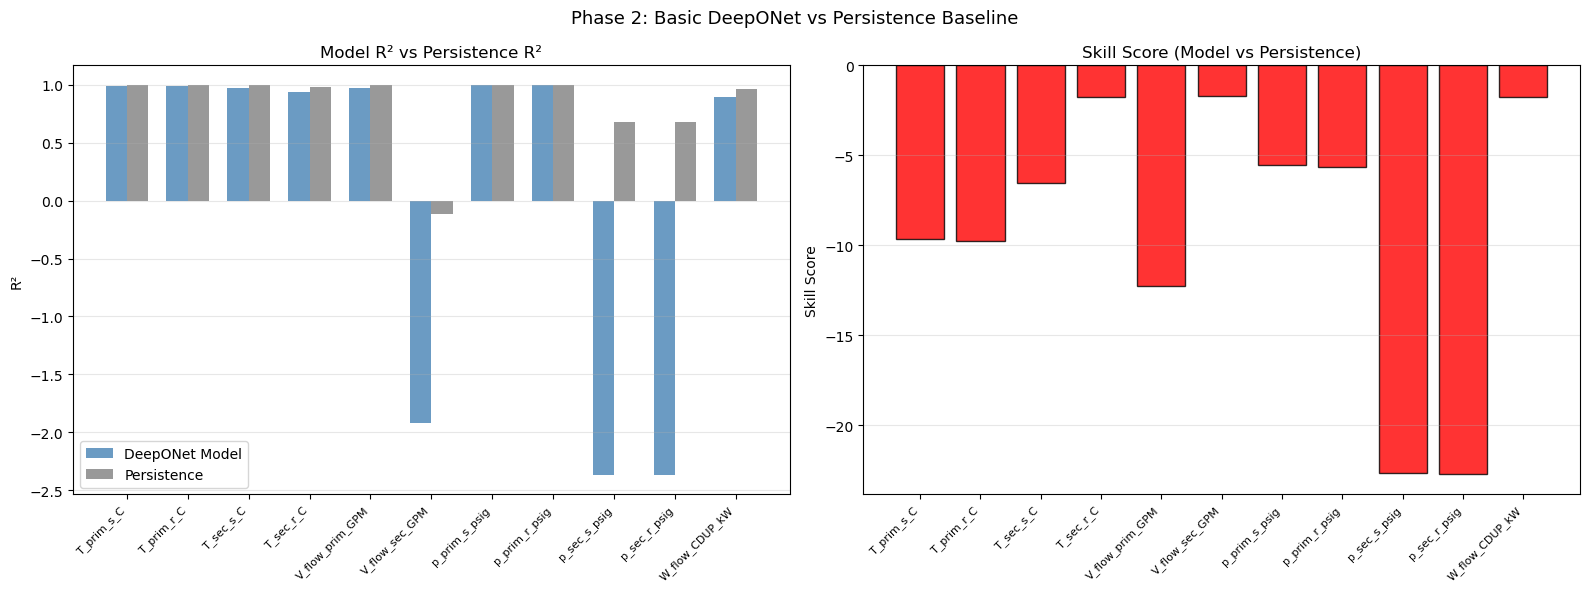

In [ ]:
#  Visualization 6 — Model vs Persistence Comparison

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_r2 = metrics_df.groupby('Type')['R²'].mean().reindex(output_types)
persist_r2 = metrics_df.groupby('Type')['Persistence_R²'].mean().reindex(output_types)

x = np.arange(len(output_types))
width = 0.35
axes[0].bar(x - width/2, model_r2, width, label='DeepONet Model', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, persist_r2, width, label='Persistence', color='gray', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(output_types, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('R²')
axes[0].set_title('Model R² vs Persistence R²')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

skill = metrics_df.groupby('Type')['Skill_Score'].mean().reindex(output_types)
colors_skill = ['green' if s > 0 else 'red' for s in skill]
axes[1].bar(x, skill, color=colors_skill, alpha=0.8, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(output_types, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Skill Score')
axes[1].set_title('Skill Score (Model vs Persistence)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Phase 2: Basic DeepONet vs Persistence Baseline', fontsize=13)
plt.tight_layout()
plt.savefig('phase_2_vis/vs_persistence.png', dpi=150, bbox_inches='tight')
plt.show()

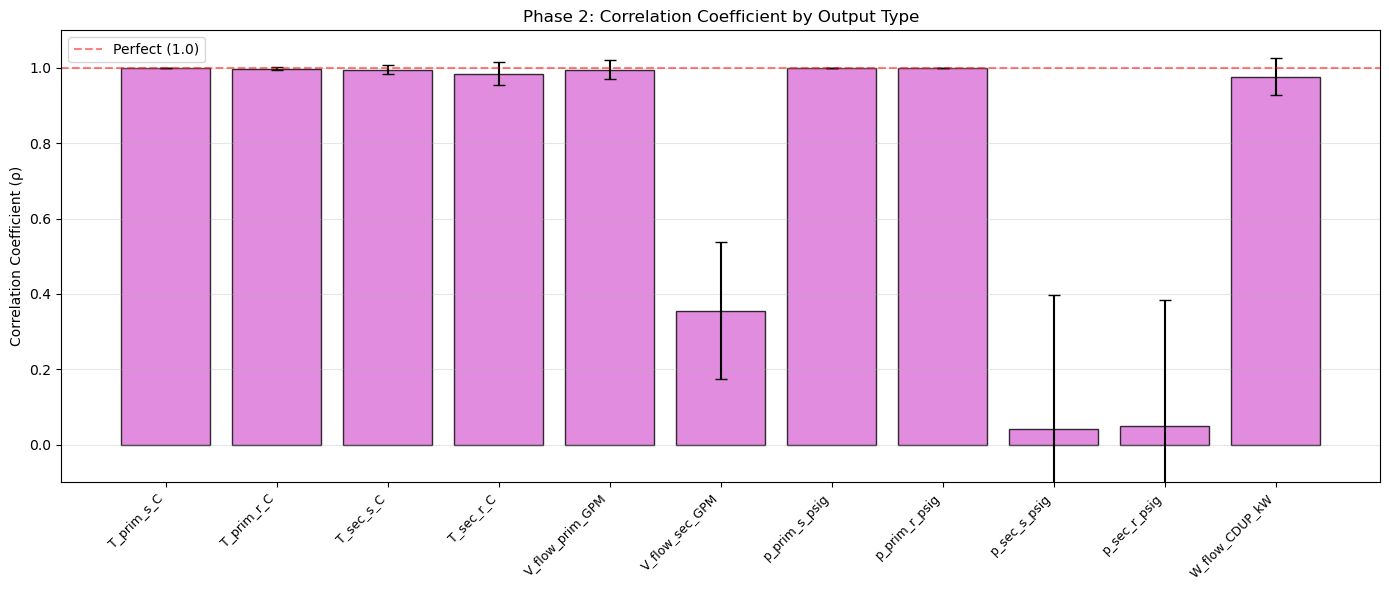

In [ ]:
#  Visualization 7 — Correlation Coefficient by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_corr = metrics_df.groupby('Type')['Correlation'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_corr['mean'], yerr=type_corr['std'], capsize=4,
              color='orchid', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Correlation Coefficient (ρ)')
ax.set_title('Phase 2: Correlation Coefficient by Output Type')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect (1.0)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.savefig('phase_2_vis/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Time-Series Predictions (300-second sample)

For each output type and CDU, a 300-second window comparing:
- **Actual** (ground truth) values
- **Model prediction** (DeepONet)
- **Persistence baseline** (last observed value)

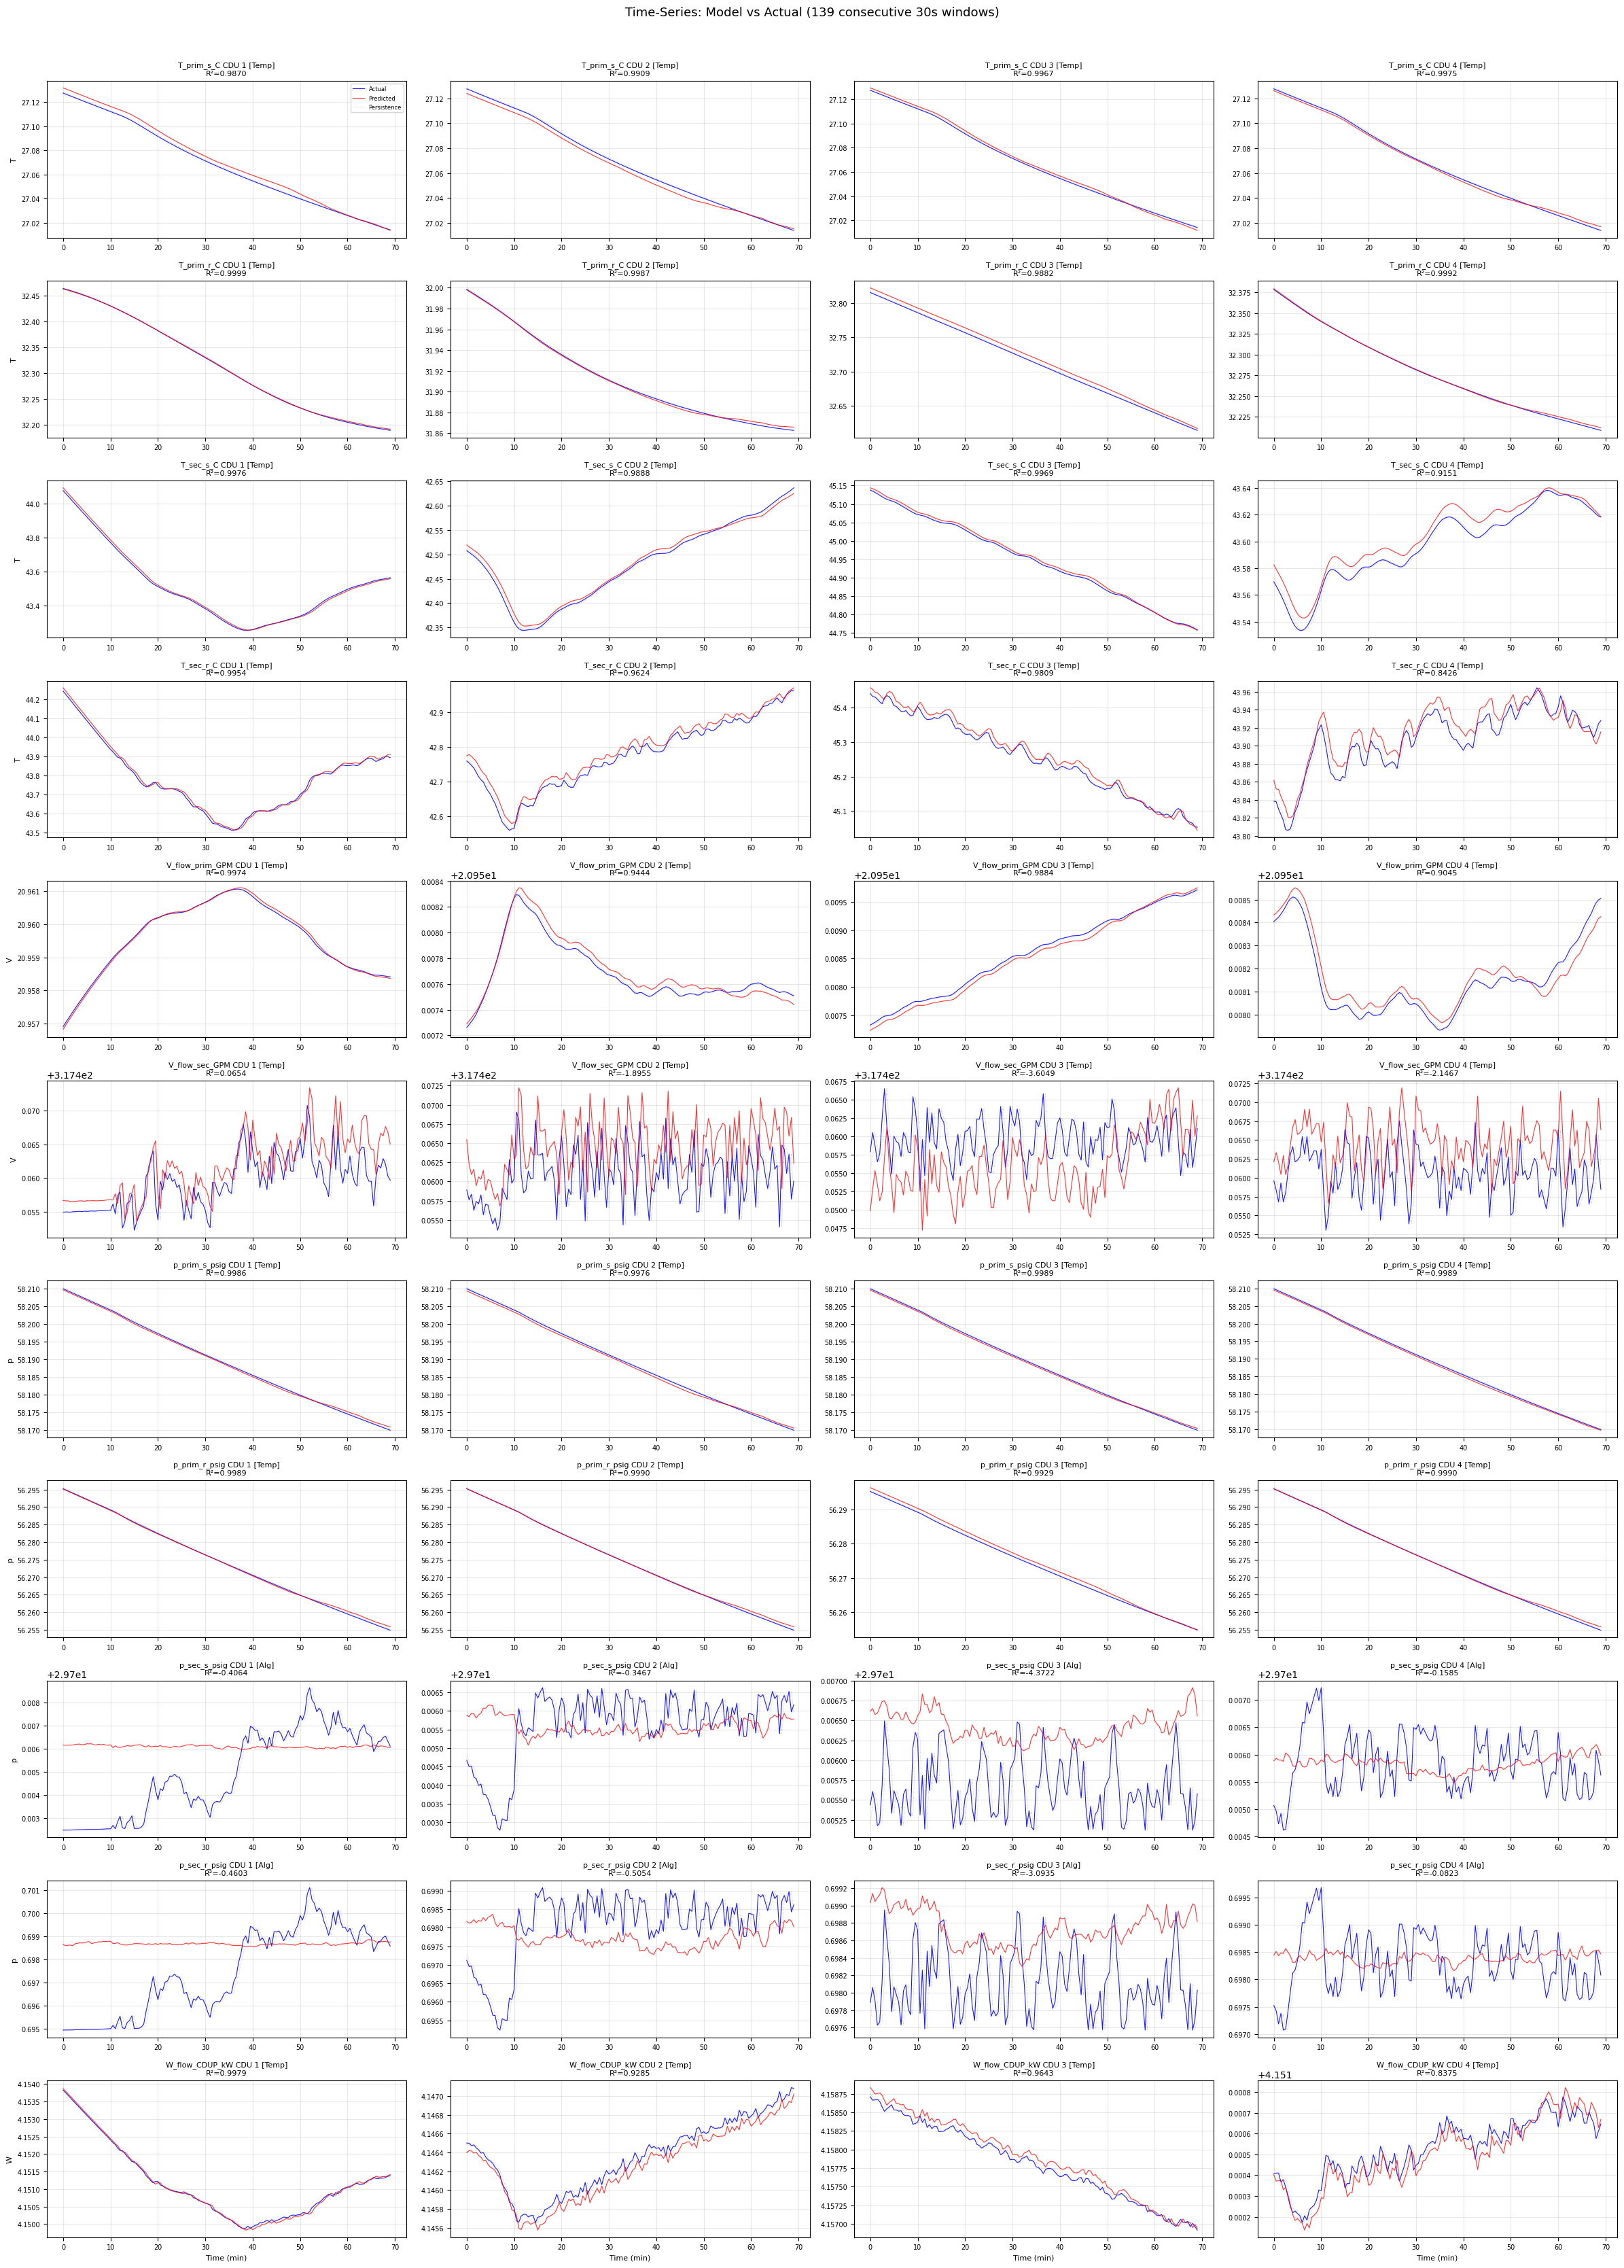

In [ ]:
#  Time-Series Predictions — Chain consecutive prediction windows
# (matching dl_12_federated_DeepM&Mnet.ipynb style)

def plot_timeseries_predictions(predictions_dict, column_info, config,
                                 n_cdus=4, n_samples_show=200):
    """
    Chain consecutive prediction windows into a continuous time-series
    for every output type × selected CDUs.
    """
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_out = predictions_dict['last_output']
    output_cols = column_info['output_cols']

    K = config.PREDICTION_STEPS
    dt = config.SUBSAMPLE_FACTOR   # seconds per step

    N = min(n_samples_show, pred.shape[0])
    cdu_ids = config.CDU_IDS[:n_cdus]

    output_names = config.OUTPUT_NAMES
    n_types = len(output_names)

    fig, axes = plt.subplots(n_types, n_cdus, figsize=(6 * n_cdus, 3.0 * n_types),
                             squeeze=False)

    for row, output_type in enumerate(output_names):
        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]

            pattern = config.OUTPUT_PATTERNS[output_type]
            col_name = pattern.format(cdu_id)
            if col_name not in output_cols:
                ax.set_visible(False)
                continue
            idx = output_cols.index(col_name)

            # Build time-series from consecutive prediction windows
            t_vals, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_vals.append(t_sec)
                    y_actual.append(target[i, k, idx])
                    y_pred.append(pred[i, k, idx])
                    y_persist.append(last_out[i, idx])

            t_min = np.array(t_vals) / 60.0
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_min, y_actual, 'b-', label='Actual', linewidth=0.8, alpha=0.9)
            ax.plot(t_min, y_pred, 'r-', label='Predicted', linewidth=0.8, alpha=0.8)
            ax.plot(t_min, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            # Compute R² for this specific output
            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)

            pathway = 'Alg' if output_type in config.ALGEBRAIC_OUTPUTS else 'Temp'
            ax.set_title(f'{output_type} CDU {cdu_id} [{pathway}]\nR²={r2:.4f}', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type.split('_')[0], fontsize=8)
            if row == n_types - 1:
                ax.set_xlabel('Time (min)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Time-Series: Model vs Actual ({N} consecutive {K*dt}s windows)',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig('phase_2_vis/timeseries_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_timeseries_predictions(predictions_dict, column_info, config)

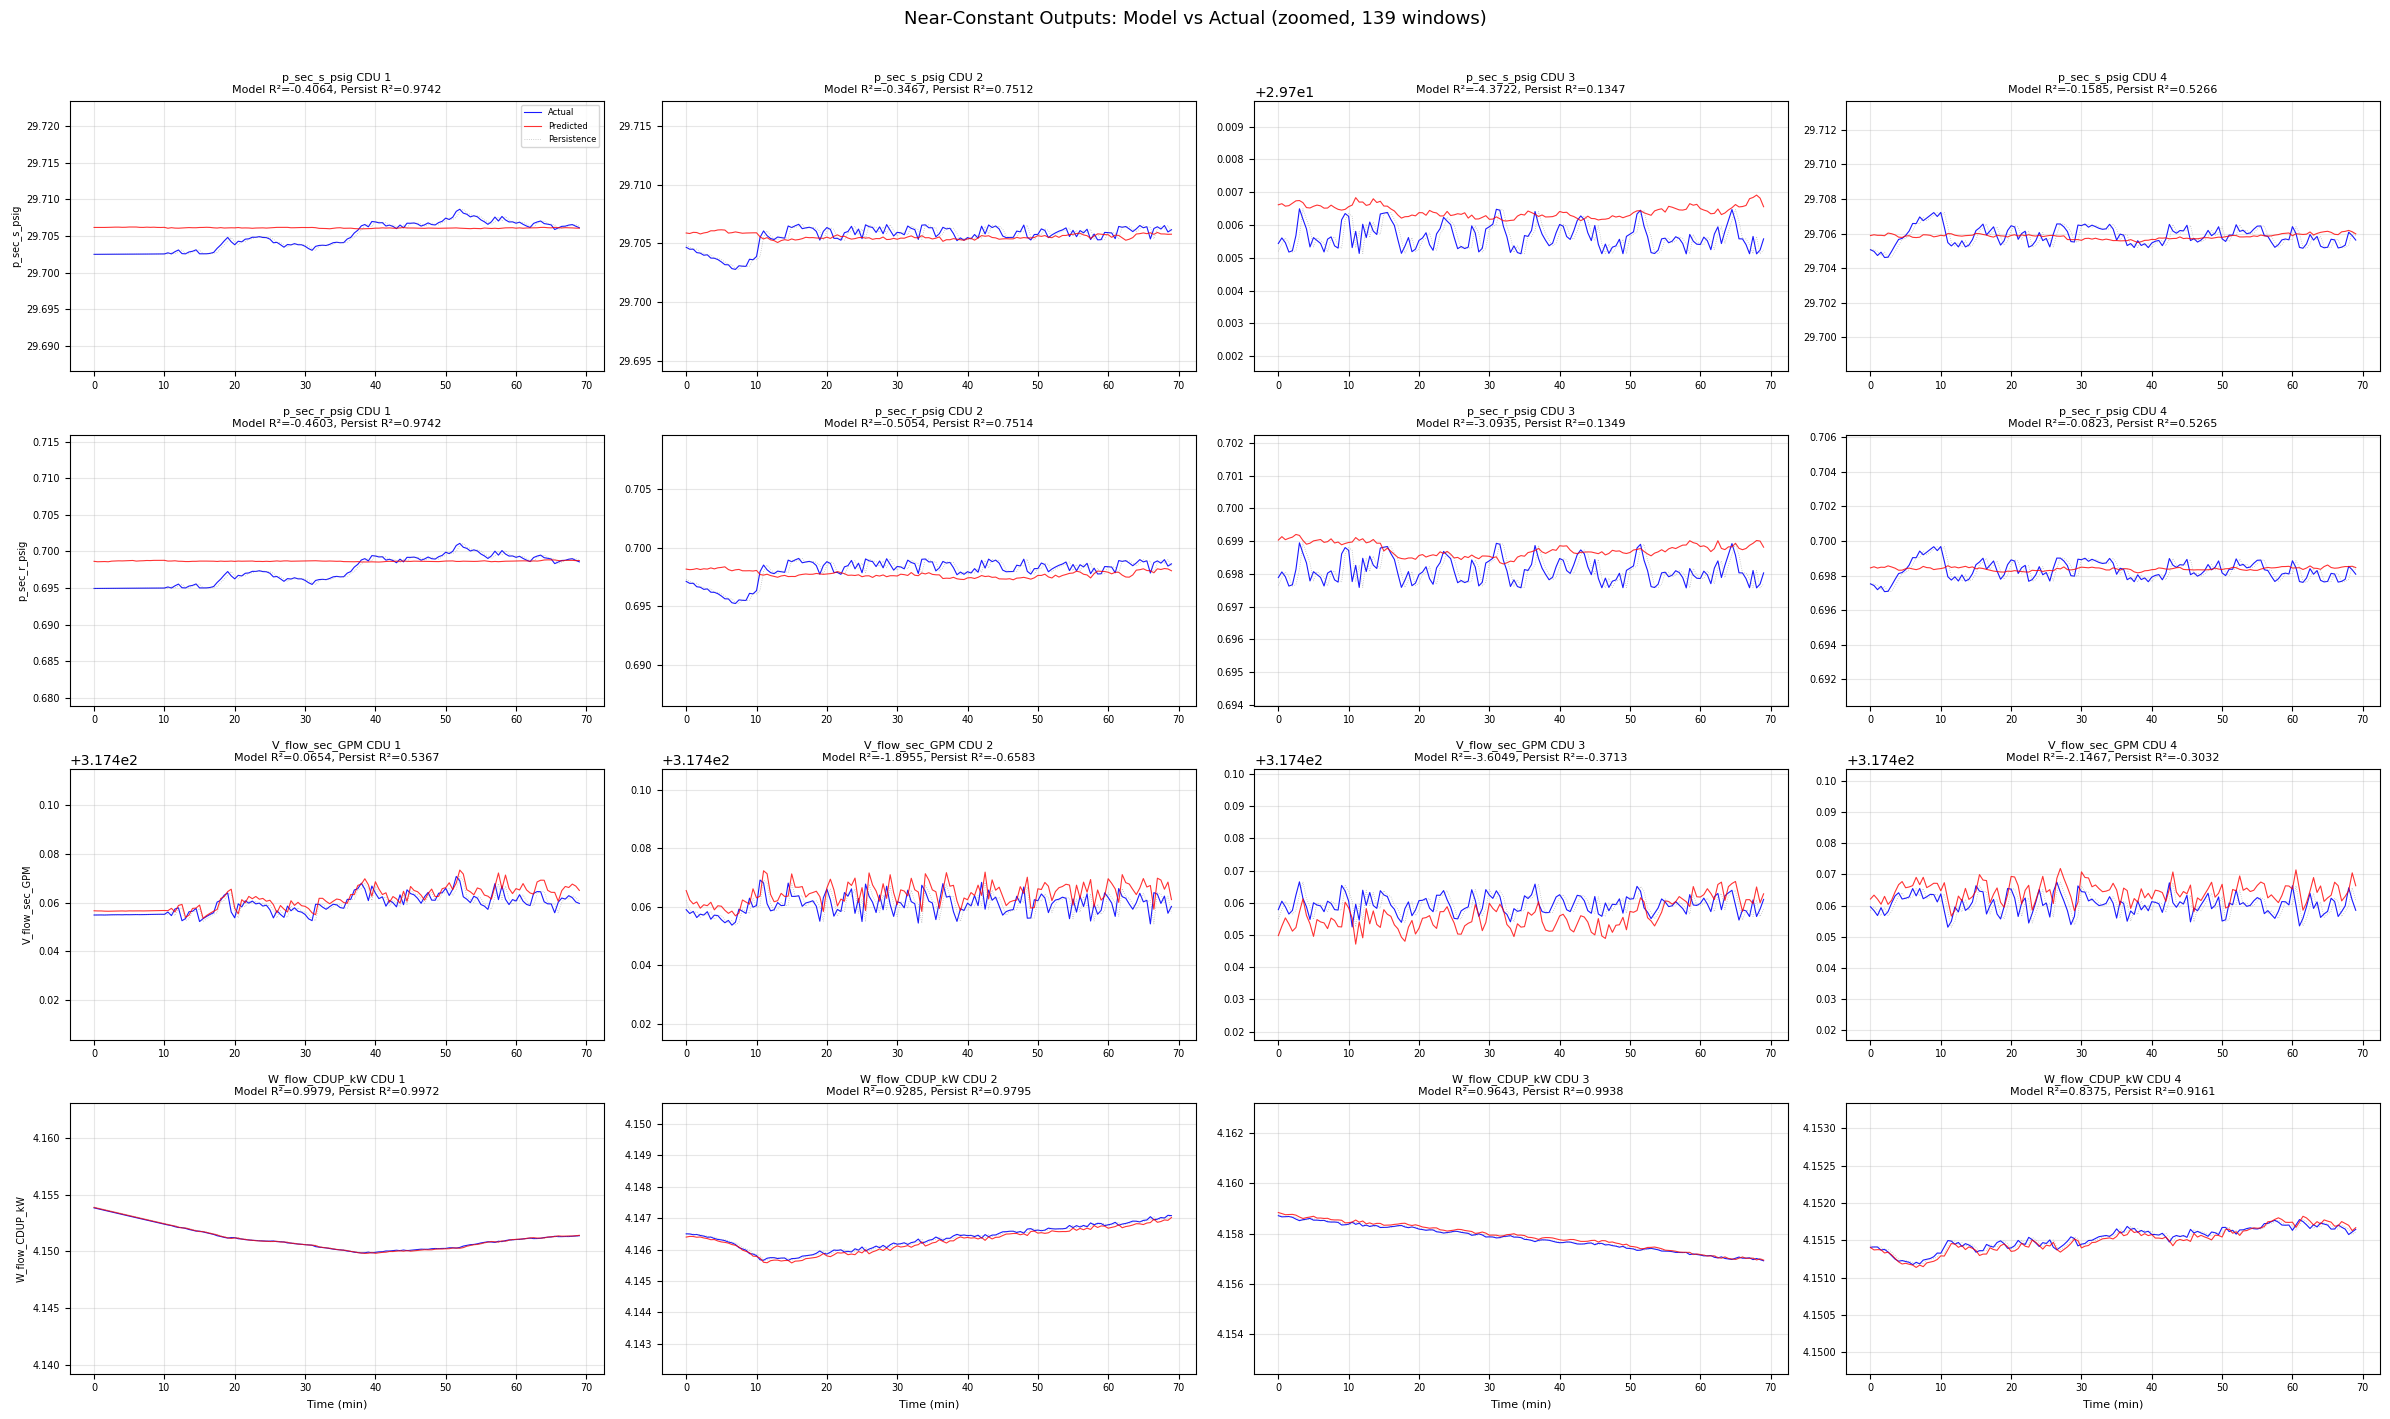

In [ ]:
#  Near-Constant Output Time-Series (Zoomed)

def plot_timeseries_nearconst(predictions_dict, column_info, config,
                               n_cdus=4, n_samples_show=200):
    """
    Dedicated time-series for near-constant outputs (Category D, E).
    Y-axis zoomed to ±3× data range for visibility of tiny fluctuations.
    """
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_out = predictions_dict['last_output']
    output_cols = column_info['output_cols']

    nearconst_types = config.CATEGORY_D + config.CATEGORY_E
    n_types = len(nearconst_types)
    K = config.PREDICTION_STEPS
    dt = config.SUBSAMPLE_FACTOR
    N = min(n_samples_show, pred.shape[0])

    cdu_ids = config.CDU_IDS[:n_cdus]

    fig, axes = plt.subplots(n_types, n_cdus, figsize=(6 * n_cdus, 3.5 * n_types),
                             squeeze=False)

    for row, output_type in enumerate(nearconst_types):
        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]

            pattern = config.OUTPUT_PATTERNS[output_type]
            col_name = pattern.format(cdu_id)
            if col_name not in output_cols:
                ax.set_visible(False)
                continue
            idx = output_cols.index(col_name)

            t_vals, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_vals.append(t_sec)
                    y_actual.append(target[i, k, idx])
                    y_pred.append(pred[i, k, idx])
                    y_persist.append(last_out[i, idx])

            t_min = np.array(t_vals) / 60.0
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_min, y_actual, 'b-', label='Actual', linewidth=0.8, alpha=0.9)
            ax.plot(t_min, y_pred, 'r-', label='Predicted', linewidth=0.8, alpha=0.8)
            ax.plot(t_min, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            # Zoom to ±3× range for visibility
            y_mean = y_actual.mean()
            y_range = max(y_actual.max() - y_actual.min(), 1e-4)
            margin = y_range * 3
            ax.set_ylim(y_mean - margin, y_mean + margin)

            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)

            ss_res_p = np.sum((y_actual - y_persist) ** 2)
            r2_p = 1 - ss_res_p / (ss_tot + 1e-10)

            ax.set_title(f'{output_type} CDU {cdu_id}\nModel R²={r2:.4f}, '
                         f'Persist R²={r2_p:.4f}', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type, fontsize=7)
            if row == n_types - 1:
                ax.set_xlabel('Time (min)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Near-Constant Outputs: Model vs Actual (zoomed, {N} windows)',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig('phase_2_vis/timeseries_nearconst.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_timeseries_nearconst(predictions_dict, column_info, config)

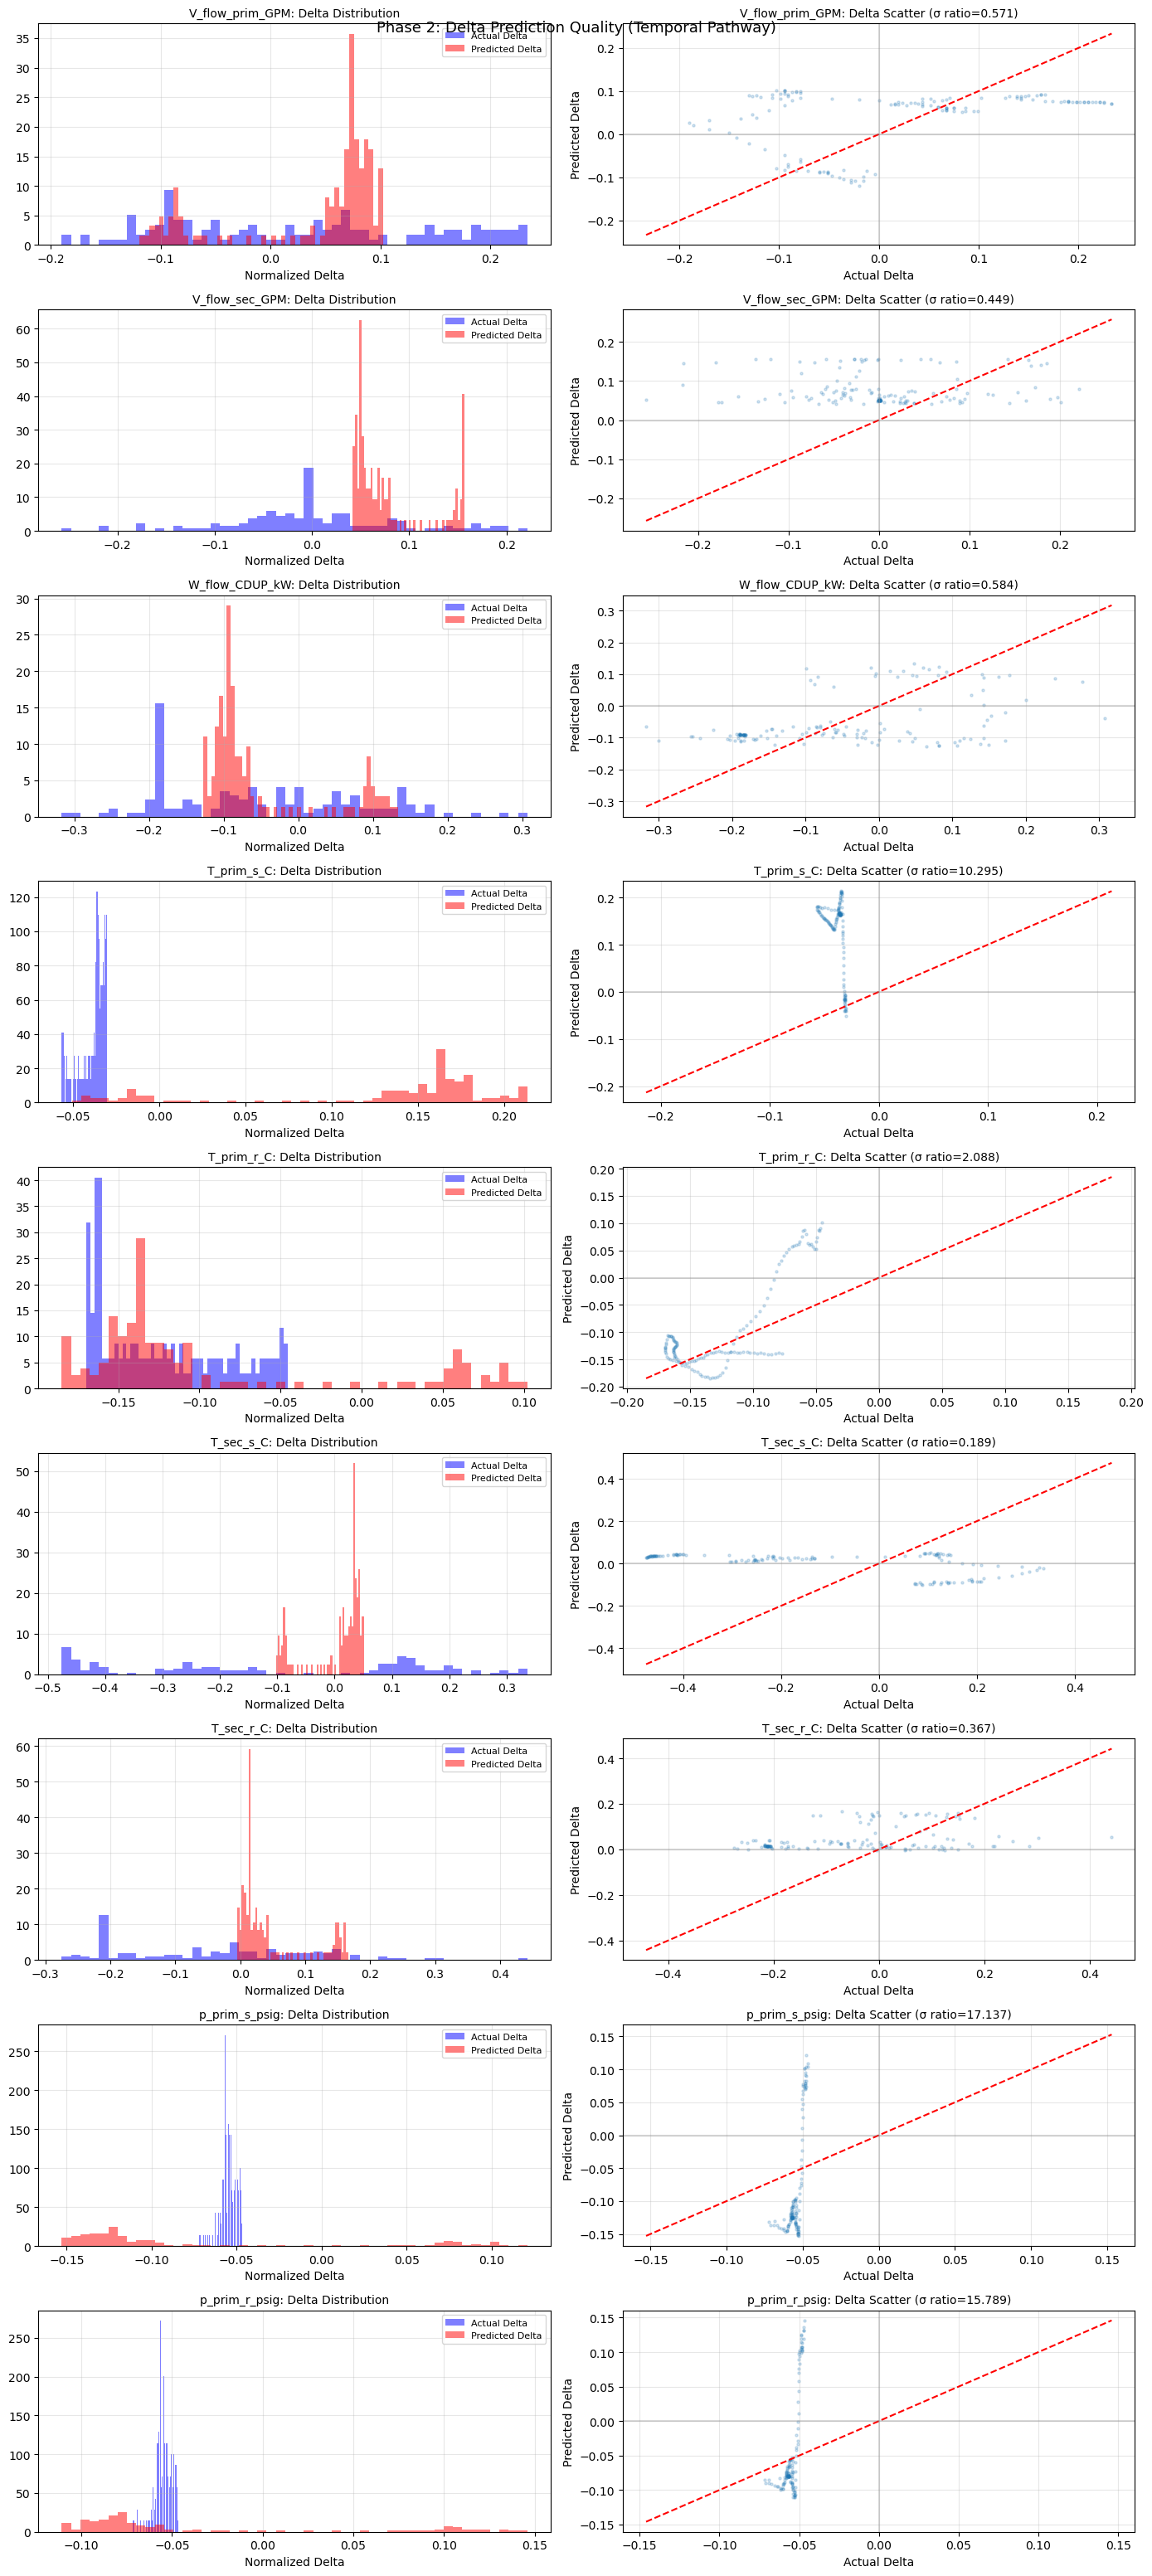

In [ ]:
#  Visualization 8 — Delta Prediction Quality (Temporal Pathway)

def plot_delta_quality(predictions_dict, column_info, config):
    """Visualize delta prediction quality for temporal outputs."""
    pred_norm = predictions_dict['pred_temporal_norm']
    target_norm = predictions_dict['target_temporal_norm']
    temporal_cols = column_info['temporal_cols']

    # Select one column per temporal output type
    type_examples = {}
    for t_idx, col in enumerate(temporal_cols):
        otype = column_info['col_to_type'].get(col)
        if otype not in type_examples:
            type_examples[otype] = t_idx

    n_types = len(type_examples)
    fig, axes = plt.subplots(n_types, 2, figsize=(14, 3.5 * n_types))
    if n_types == 1:
        axes = axes.reshape(1, -1)

    for row, (otype, t_idx) in enumerate(type_examples.items()):
        pred_d = pred_norm[:, 0, t_idx]
        true_d = target_norm[:, 0, t_idx]

        ax = axes[row, 0]
        ax.hist(true_d, bins=50, alpha=0.5, label='Actual Delta', density=True, color='blue')
        ax.hist(pred_d, bins=50, alpha=0.5, label='Predicted Delta', density=True, color='red')
        ax.set_title(f'{otype}: Delta Distribution', fontsize=10)
        ax.set_xlabel('Normalized Delta')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = axes[row, 1]
        n_plot = min(3000, len(pred_d))
        plot_idx = np.random.choice(len(pred_d), n_plot, replace=False)
        ax.scatter(true_d[plot_idx], pred_d[plot_idx], alpha=0.2, s=5)
        lim = max(np.abs(true_d).max(), np.abs(pred_d).max())
        ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5)
        ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
        ax.axvline(0, color='gray', linestyle='-', alpha=0.3)

        std_ratio = np.std(pred_d) / (np.std(true_d) + 1e-10)
        ax.set_title(f'{otype}: Delta Scatter (σ ratio={std_ratio:.3f})', fontsize=10)
        ax.set_xlabel('Actual Delta')
        ax.set_ylabel('Predicted Delta')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Phase 2: Delta Prediction Quality (Temporal Pathway)', fontsize=13)
    plt.tight_layout()
    plt.savefig('phase_2_vis/delta_quality.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_delta_quality(predictions_dict, column_info, config)

## Save Results

In [ ]:
#  Save Model, Metrics, and Training History

save_dir = Path('./saved_models/phase2_basic_deeponet')
save_dir.mkdir(parents=True, exist_ok=True)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'config': {
        'DEEPONET_HIDDEN': config.DEEPONET_HIDDEN,
        'DEEPONET_N_BASIS': config.DEEPONET_N_BASIS,
        'ALGEBRAIC_HIDDEN': config.ALGEBRAIC_HIDDEN,
        'ALGEBRAIC_LAYERS': config.ALGEBRAIC_LAYERS,
        'DROPOUT': config.DROPOUT,
        'HISTORY_STEPS': config.HISTORY_STEPS,
        'PREDICTION_STEPS': config.PREDICTION_STEPS,
        'SUBSAMPLE_FACTOR': config.SUBSAMPLE_FACTOR,
        'USE_INPUT_WHITENING': config.USE_INPUT_WHITENING,
        'temporal_input_size': temporal_input_size,
        'temporal_output_size': temporal_output_size,
        'algebraic_input_size': algebraic_input_size,
        'algebraic_output_size': algebraic_output_size,
    },
    'training': {
        'epochs': n_epochs_trained,
        'best_val_loss': early_stopping.best_loss,
        'training_time_sec': train_time,
        'total_params': total_params,
        'temporal_params': temporal_params,
        'algebraic_params': algebraic_params,
    },
}
torch.save(checkpoint, save_dir / 'phase2_deeponet_best.pth')
print(f"Model saved to: {save_dir / 'phase2_deeponet_best.pth'}")

metrics_df.to_csv(save_dir / 'metrics.csv', index=False)
print(f"Metrics saved to: {save_dir / 'metrics.csv'}")

with open(save_dir / 'training_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.items()}, f, indent=2)
print(f"Training history saved to: {save_dir / 'training_history.json'}")

Model saved to: saved_models/phase2_basic_deeponet/phase2_deeponet_best.pth
Metrics saved to: saved_models/phase2_basic_deeponet/metrics.csv
Training history saved to: saved_models/phase2_basic_deeponet/training_history.json


In [ ]:
#  Final Summary

print("\n" + "=" * 70)
print("PHASE 2: BASIC DEEPONET — FINAL SUMMARY")
print("=" * 70)

print(f"\nArchitecture:")
print(f"  Temporal: LSTM Branch ({config.DEEPONET_HIDDEN}) + Fourier Trunk → {config.DEEPONET_N_BASIS} basis")
print(f"  Algebraic: 3-layer MLP (Q_flow → p_sec)")
print(f"  Total parameters: {total_params:,} (temporal: {temporal_params:,}, algebraic: {algebraic_params:,})")
print(f"  Prediction mode:  delta (temporal), absolute (algebraic)")
print(f"  Input whitening:  PCA ({config.WHITENING_COMPONENTS:.0%} variance)")

print(f"\nTraining:")
print(f"  Loss:             Huber+VarMatch (temporal) + MSE (algebraic)")
print(f"  Optimizer:        AdamW (lr={config.LEARNING_RATE}, wd={config.WEIGHT_DECAY})")
print(f"  Scheduler:        Cosine annealing (T₀=20, T_mult=2)")
print(f"  Epochs:           {n_epochs_trained} (patience {config.PATIENCE})")
print(f"  Training time:    {train_time:.0f}s")

print(f"\nData:")
print(f"  History:          {config.HISTORY_SECONDS}s ({config.HISTORY_STEPS} steps)")
print(f"  Prediction:       {config.PREDICTION_SECONDS}s ({config.PREDICTION_STEPS} steps)")
print(f"  CDUs:             {config.NUM_CDUS}")
print(f"  Total outputs:    {len(metrics_df)}")
print(f"  Temporal:         {len(column_info['temporal_cols'])}")
print(f"  Algebraic:        {len(column_info['algebraic_cols'])}")

print(f"\nPerformance (Test Set):")
print(f"  Mean R²:            {metrics_df['R²'].mean():.4f}")
print(f"  Median R²:          {metrics_df['R²'].median():.4f}")
print(f"  Outputs R² > 0.8:   {(metrics_df['R²'] > 0.8).sum()}/{len(metrics_df)}")
print(f"  Outputs R² > 0.9:   {(metrics_df['R²'] > 0.9).sum()}/{len(metrics_df)}")
print(f"  Variance Ratio:     {metrics_df['Variance_Ratio'].mean():.4f}")
print(f"  Beats Persistence:  {metrics_df['Beats_Persistence'].sum()}/{len(metrics_df)}")

print(f"\nPer-Category Performance:")
for cat in ['A (Primary loop)', 'B (Secondary temp)', 'C (Primary flow)',
            'D (Secondary pressure)', 'E (Constant)']:
    cat_df = metrics_df[metrics_df['Category'] == cat]
    if len(cat_df) == 0:
        continue
    r2_mean = cat_df['R²'].mean()
    status = 'Excellent' if r2_mean > 0.9 else ('Good' if r2_mean > 0.7 else ('Fair' if r2_mean > 0.3 else 'Poor'))
    print(f"  {cat}: Mean R²={r2_mean:.4f} ({status}, {len(cat_df)} outputs)")

print(f"\nInference:")
print(f"  Total time:       {inference_time:.2f}s")
print(f"  Per sample:       {inference_time/n_test_samples*1000:.2f} ms")


PHASE 2: BASIC DEEPONET — FINAL SUMMARY

Architecture:
  Temporal: LSTM Branch (64) + Fourier Trunk → 32 basis
  Algebraic: 3-layer MLP (Q_flow → p_sec)
  Total parameters: 5,597,397 (temporal: 5,543,059, algebraic: 54,338)
  Prediction mode:  delta (temporal), absolute (algebraic)
  Input whitening:  PCA (99% variance)

Training:
  Loss:             Huber+VarMatch (temporal) + MSE (algebraic)
  Optimizer:        AdamW (lr=0.001, wd=0.0001)
  Scheduler:        Cosine annealing (T₀=20, T_mult=2)
  Epochs:           23 (patience 20)
  Training time:    42s

Data:
  History:          1200s (40 steps)
  Prediction:       30s (1 steps)
  CDUs:             257
  Total outputs:    2827
  Temporal:         2313
  Algebraic:        514

Performance (Test Set):
  Mean R²:            0.0993
  Median R²:          0.9900
  Outputs R² > 0.8:   1992/2827
  Outputs R² > 0.9:   1921/2827
  Variance Ratio:     0.9096
  Beats Persistence:  144/2827

Per-Category Performance:
  A (Primary loop): Mean R²=